In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

# load all years
combined = pd.concat([pd.read_csv(f, low_memory=False) for f in glob.glob('*_amazon.csv')], ignore_index=True)

# fix order_date dtype
combined['order_date'] = pd.to_datetime(combined['order_date'])

print(f"Shape: {combined.shape}")
print(combined.dtypes)

Shape: (1121999, 34)
transaction_id                    object
order_date                datetime64[ns]
customer_id                       object
product_id                        object
product_name                      object
category                          object
subcategory                       object
brand                             object
original_price_inr               float64
discount_percent                 float64
discounted_price_inr             float64
quantity                           int64
subtotal_inr                     float64
delivery_charges                 float64
final_amount_inr                 float64
customer_city                     object
customer_state                    object
customer_tier                     object
customer_spending_tier            object
customer_age_group                object
payment_method                    object
delivery_days                    float64
delivery_type                     object
is_prime_member                     

EDA-1

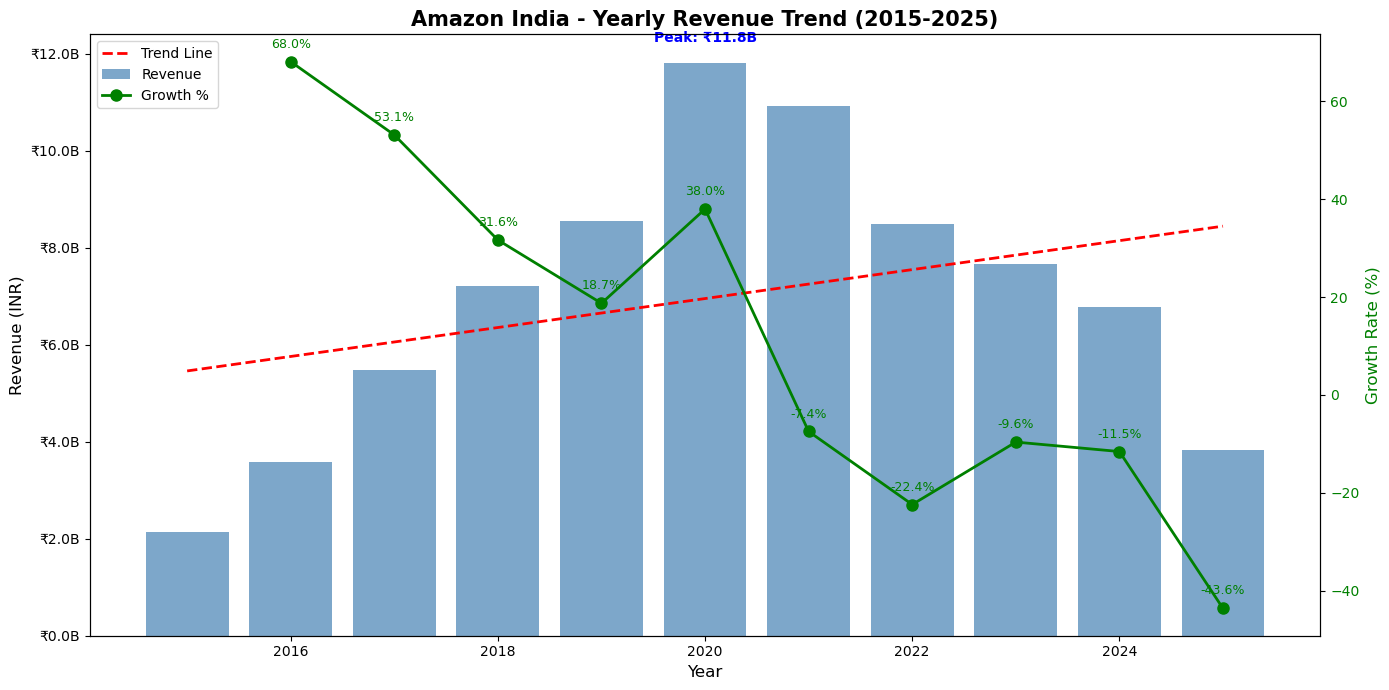

EDA 1
    year       revenue   growth_%
0   2015  2.130499e+09        NaN
1   2016  3.579914e+09  68.031715
2   2017  5.479954e+09  53.075004
3   2018  7.213276e+09  31.630225
4   2019  8.563455e+09  18.717971
5   2020  1.181364e+10  37.954126
6   2021  1.093411e+10  -7.445016
7   2022  8.489730e+09 -22.355558
8   2023  7.673823e+09  -9.610517
9   2024  6.788208e+09 -11.540724
10  2025  3.831697e+09 -43.553631


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# yearly revenue
yearly_revenue = combined.groupby('order_year')['final_amount_inr'].sum().reset_index()
yearly_revenue.columns = ['year', 'revenue']
yearly_revenue['growth_%'] = yearly_revenue['revenue'].pct_change() * 100

# plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# bar chart for revenue
bars = ax1.bar(yearly_revenue['year'], yearly_revenue['revenue'], 
               color='steelblue', alpha=0.7, label='Revenue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Revenue (INR)', fontsize=12)
ax1.set_title('Amazon India - Yearly Revenue Trend (2015-2025)', fontsize=15, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e9:.1f}B'))

# trend line
z = np.polyfit(yearly_revenue['year'], yearly_revenue['revenue'], 1)
p = np.poly1d(z)
ax1.plot(yearly_revenue['year'], p(yearly_revenue['year']), 
         'r--', linewidth=2, label='Trend Line')

# growth % on second axis
ax2 = ax1.twinx()
ax2.plot(yearly_revenue['year'], yearly_revenue['growth_%'], 
         'go-', linewidth=2, markersize=8, label='Growth %')
ax2.set_ylabel('Growth Rate (%)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# annotations for growth %
for i, row in yearly_revenue.iterrows():
    if not np.isnan(row['growth_%']):
        ax2.annotate(f"{row['growth_%']:.1f}%", 
                    xy=(row['year'], row['growth_%']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='green')

# highlight highest revenue year
max_year = yearly_revenue.loc[yearly_revenue['revenue'].idxmax()]
ax1.annotate(f"Peak: ₹{max_year['revenue']/1e9:.1f}B",
            xy=(max_year['year'], max_year['revenue']),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=10, color='blue', fontweight='bold')

# legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('eda_q1_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA 1")
print(yearly_revenue)

EDA-2

In [4]:
print(combined['order_month'].unique())
print(combined['order_year'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]
[2023 2019 2024 2021 2016 2015 2022 2018 2020 2017 2025]


In [5]:
monthly_revenue = combined.groupby(['order_year', 'order_month'])['final_amount_inr'].sum().reset_index()
print(monthly_revenue.head(15))

    order_year  order_month  final_amount_inr
0         2015            1      1.623470e+08
1         2015            2      1.432454e+08
2         2015            3      1.447698e+08
3         2015            4      1.768368e+08
4         2015            5      1.562324e+08
5         2015            6      1.391164e+08
6         2015            7      1.544180e+08
7         2015            8      1.698275e+08
8         2015            9      1.701915e+08
9         2015           10      2.109329e+08
10        2015           11      2.316429e+08
11        2015           12      2.709384e+08
12        2016            1      2.684566e+08
13        2016            2      2.447211e+08
14        2016            3      2.426527e+08


In [6]:
pivot = monthly_revenue.pivot(index='order_year', columns='order_month', values='final_amount_inr')
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(pivot)

                     Jan           Feb           Mar           Apr  \
order_year                                                           
2015        1.623470e+08  1.432454e+08  1.447698e+08  1.768368e+08   
2016        2.684566e+08  2.447211e+08  2.426527e+08  2.868084e+08   
2017        4.103885e+08  3.731158e+08  3.690099e+08  4.567360e+08   
2018        5.382237e+08  4.838320e+08  4.766944e+08  6.036654e+08   
2019        6.562985e+08  5.605278e+08  5.869955e+08  7.052584e+08   
2020        1.008085e+09  9.092848e+08  7.936956e+08  9.805979e+08   
2021        9.373496e+08  8.438570e+08  7.424585e+08  8.950371e+08   
2022        7.199606e+08  6.554490e+08  5.727039e+08  6.876265e+08   
2023        6.477847e+08  5.834514e+08  5.078658e+08  6.344994e+08   
2024        5.760375e+08  5.120280e+08  4.508731e+08  5.565837e+08   
2025        3.232328e+08  2.927502e+08  2.556530e+08  3.165437e+08   

                     May           Jun           Jul           Aug  \
order_year         

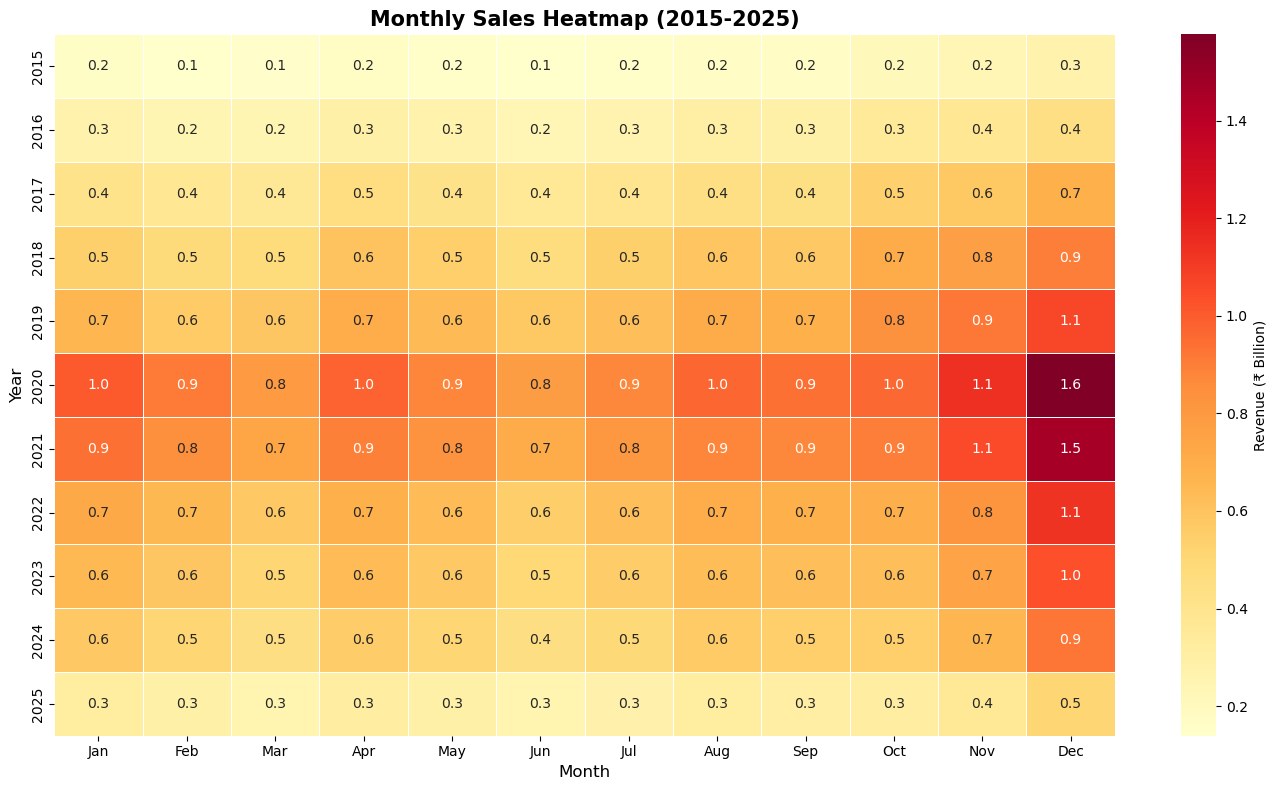

In [7]:
plt.figure(figsize=(14, 8))

sns.heatmap(pivot/1e9,  
            annot=True,          
            fmt='.1f',           
            cmap='YlOrRd',       
            linewidths=0.5,      
            cbar_kws={'label': 'Revenue (₹ Billion)'})

plt.title('Monthly Sales Heatmap (2015-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig('eda_q2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
peak_months = monthly_revenue.loc[monthly_revenue.groupby('order_year')['final_amount_inr'].idxmax()]
peak_months.columns = ['year', 'peak_month', 'revenue']
peak_months['peak_month'] = peak_months['peak_month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})
print(peak_months)

     year peak_month       revenue
11   2015        Dec  2.709384e+08
23   2016        Dec  4.480880e+08
35   2017        Dec  6.881922e+08
47   2018        Dec  9.012046e+08
59   2019        Dec  1.063327e+09
71   2020        Dec  1.577492e+09
83   2021        Dec  1.463990e+09
95   2022        Dec  1.132721e+09
107  2023        Dec  1.036379e+09
119  2024        Dec  9.202786e+08
131  2025        Dec  5.116197e+08


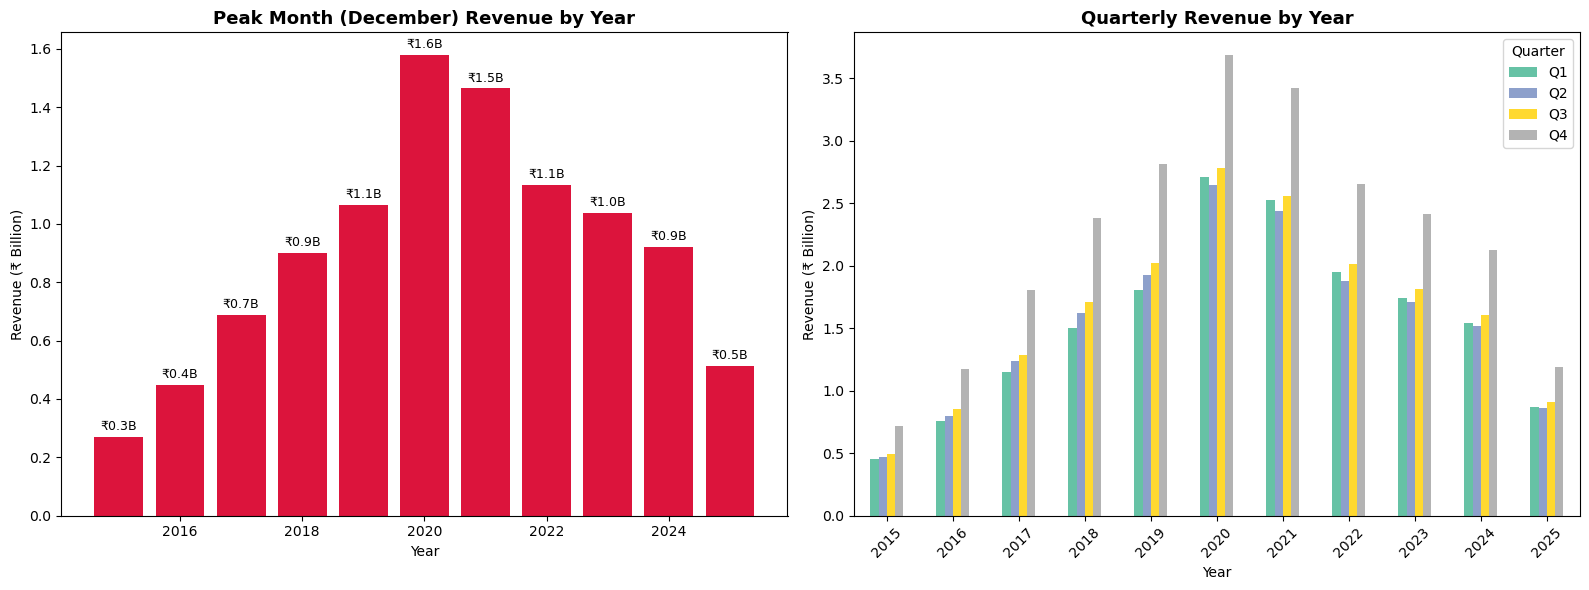

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 1 - peak month bar chart
axes[0].bar(peak_months['year'], peak_months['revenue']/1e9, color='crimson')
axes[0].set_title('Peak Month (December) Revenue by Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Revenue (₹ Billion)')
for i, row in peak_months.iterrows():
    axes[0].annotate(f"₹{row['revenue']/1e9:.1f}B",
                    xy=(row['year'], row['revenue']/1e9),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9)

# plot 2 - seasonal pattern by quarter
combined['quarter_name'] = combined['order_quarter'].map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})
quarterly = combined.groupby(['order_year', 'quarter_name'])['final_amount_inr'].sum().reset_index()
quarterly_pivot = quarterly.pivot(index='order_year', columns='quarter_name', values='final_amount_inr')/1e9

quarterly_pivot.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Quarterly Revenue by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue (₹ Billion)')
axes[1].legend(title='Quarter')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_q2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

EDA-3

In [10]:
from datetime import datetime
reference_date = combined['order_date'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")
print(f"Last transaction: {combined['order_date'].max()}")

Reference date: 2026-01-01 00:00:00
Last transaction: 2025-12-31 00:00:00


In [11]:
rfm = combined.groupby('customer_id').agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('final_amount_inr', 'sum')
).reset_index()

print(rfm.head())
print(rfm.describe())

          customer_id  recency  frequency   monetary
0  CUST_2015_00000001     2574          5  211034.56
1  CUST_2015_00000002     1420         10  632049.52
2  CUST_2015_00000003     3031          9  508294.02
3  CUST_2015_00000004     1669          8  812626.53
4  CUST_2015_00000005     2768          5  418011.46
             recency      frequency      monetary
count  354969.000000  354969.000000  3.549690e+05
mean     1365.780406       3.160837  2.155070e+05
std       863.675618       2.338920  2.372558e+05
min         1.000000       1.000000  5.821600e+02
25%       649.000000       1.000000  6.370421e+04
50%      1265.000000       2.000000  1.379024e+05
75%      1982.000000       4.000000  2.791439e+05
max      4012.000000      27.000000  3.757087e+06


In [12]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])  # lower recency = better = higher score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])  # higher frequency = better
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])  # higher monetary = better

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2: return 'Lost Customers'
    else: return 'Potential Loyalists'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['segment'].value_counts())

segment
Potential Loyalists    101495
Loyal Customers         65392
At Risk                 62438
Lost Customers          44843
Champions               41032
New Customers           39769
Name: count, dtype: int64


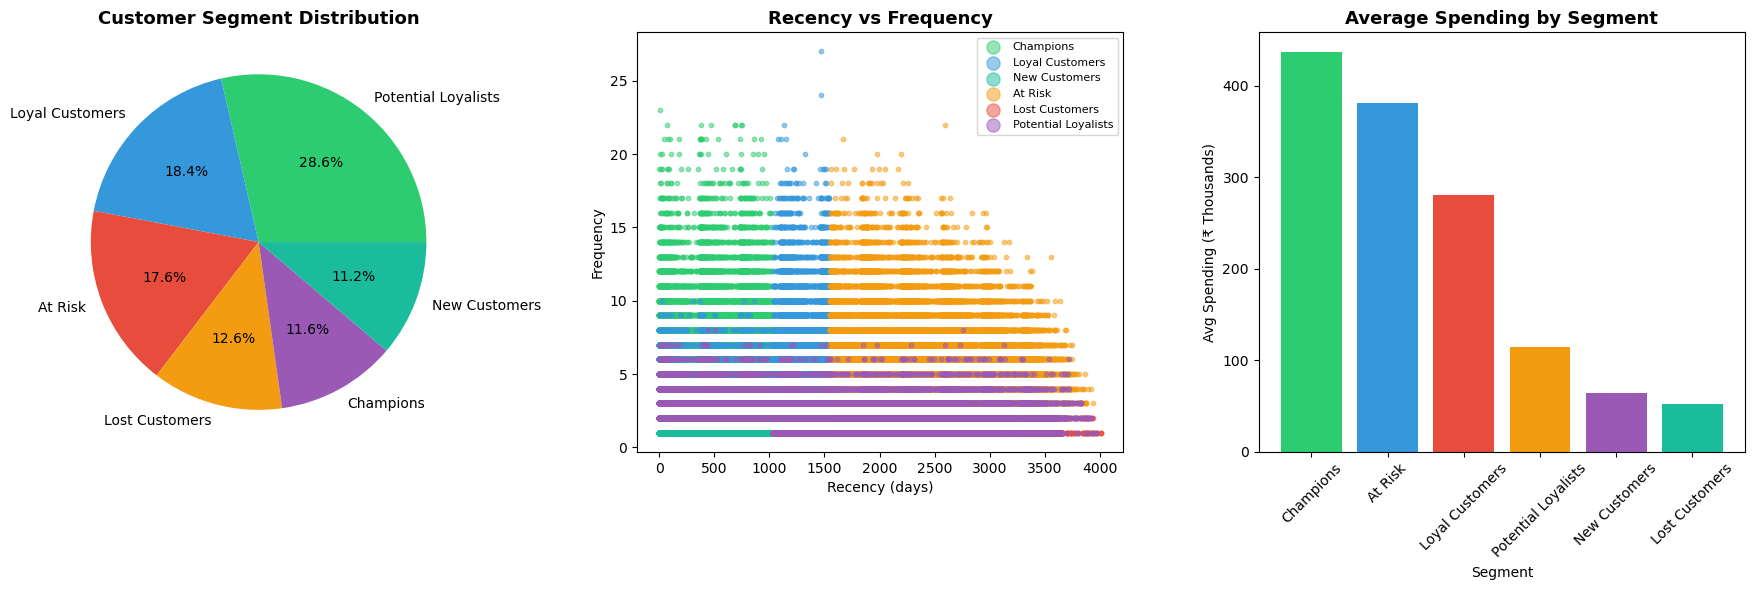

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

segment_counts = rfm['segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')

colors_map = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers': '#1abc9c',
    'At Risk': '#f39c12',
    'Lost Customers': '#e74c3c',
    'Potential Loyalists': '#9b59b6'
}
for segment, color in colors_map.items():
    mask = rfm['segment'] == segment
    axes[1].scatter(rfm[mask]['recency'], rfm[mask]['frequency'],
                   c=color, label=segment, alpha=0.5, s=10)
axes[1].set_title('Recency vs Frequency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Frequency')
axes[1].legend(markerscale=3, fontsize=8)

avg_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)
axes[2].bar(avg_monetary.index, avg_monetary/1000, color=colors)
axes[2].set_title('Average Spending by Segment', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Avg Spending (₹ Thousands)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_q3_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

EDA-4

In [14]:
payment_yearly = df.groupby(['year', 'payment_method'])['final_amount_inr'].sum().reset_index()

NameError: name 'df' is not defined

In [ ]:
pivot_payment = payment_yearly.pivot(index='year', columns='payment_method', values='final_amount_inr')
pivot_payment = pivot_payment.fillna(0)

In [ ]:
payment_share = pivot_payment.div(pivot_payment.sum(axis=1), axis=0) * 100

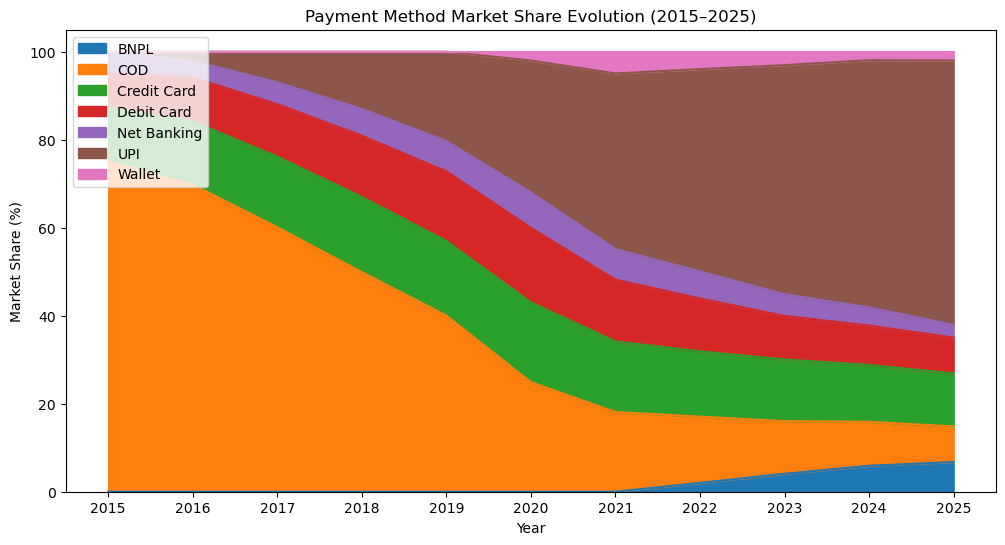

In [ ]:
import matplotlib.pyplot as plt
payment_share.plot.area(figsize=(12,6))
plt.title("Payment Method Market Share Evolution (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Market Share (%)")
plt.xticks(pivot_payment.index)
plt.legend(loc='upper left')
plt.show()

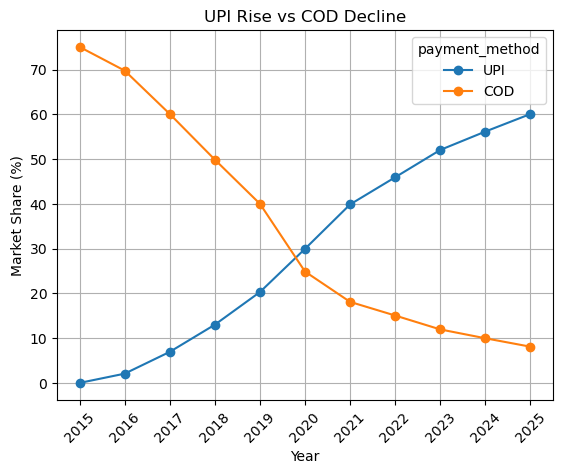

In [ ]:
important_methods = ['UPI', 'COD']  # adjust names if needed
payment_share[important_methods].plot(marker='o')
plt.title("UPI Rise vs COD Decline")
plt.xlabel("Year")
plt.ylabel("Market Share (%)")
plt.xticks(pivot_payment.index, rotation=45)
plt.grid(True)
plt.show()

EDA-5

In [ ]:
import pandas as pd
years = range(2015, 2026)
df_list = []

for year in years:
    file_path = f"/Users/Sanjay/Desktop/GUVI/Project 2/CODE/{year}_amazon.csv"
    temp_df = pd.read_csv(file_path)
    temp_df['year'] = year
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df['category'] = df['category'].str.strip().str.lower()

In [ ]:
df.columns

Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name', 'category', 'subcategory', 'brand',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible',
       'product_rating', 'year'],
      dtype='object')

In [ ]:
category_revenue = df.groupby('category')['final_amount_inr'].sum().sort_values(ascending=False)

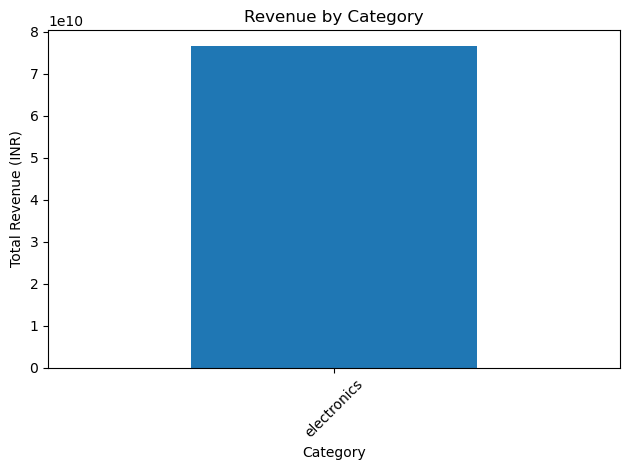

In [ ]:
import matplotlib.pyplot as plt

category_revenue.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

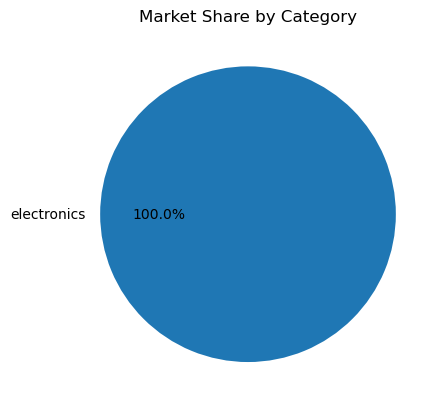

In [ ]:
category_revenue.head(8).plot(kind='pie', autopct='%1.1f%%')

plt.title("Market Share by Category")
plt.ylabel('')
plt.show()

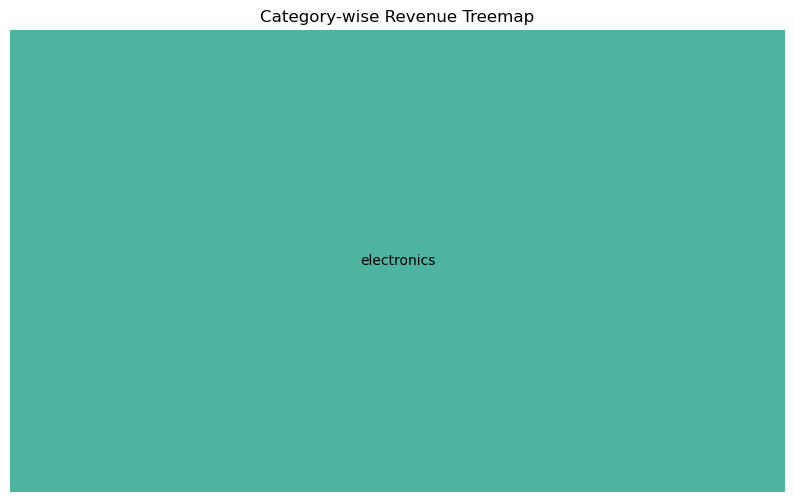

In [ ]:
import squarify

plt.figure(figsize=(10,6))

squarify.plot(
    sizes=category_revenue.values,
    label=category_revenue.index,
    alpha=0.8
)

plt.title("Category-wise Revenue Treemap")
plt.axis('off')
plt.show()

In [ ]:
yearly_category = df.groupby(['year', 'category'])['final_amount_inr'].sum().reset_index()

In [ ]:
pivot_table = yearly_category.pivot(index='year', columns='category', values='final_amount_inr')

In [ ]:
growth_rate = pivot_table.pct_change() * 100

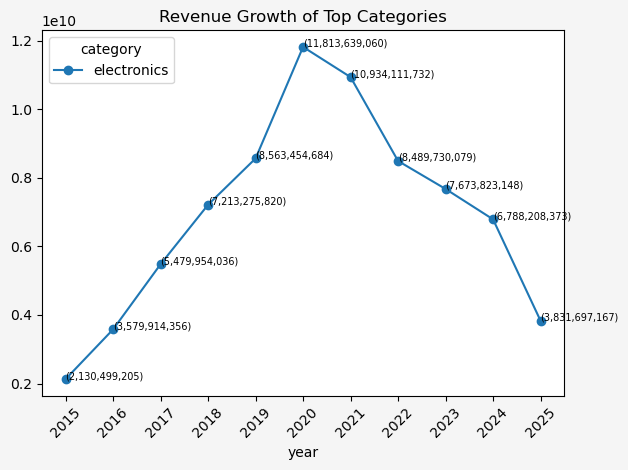

In [ ]:
fig, ax = plt.subplots()
fig.patch.set_facecolor('#f5f5f5')   
ax.set_facecolor('#ffffff')          
pivot_table[top_categories].plot(marker='o', ax=ax)
plt.title("Revenue Growth of Top Categories")
plt.xticks(pivot_table.index, rotation=45)
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y, f'({int(y):,})', fontsize=7)

plt.tight_layout()
plt.show()

EDA-6

In [ ]:
aov = df.groupby('is_prime_member')['final_amount_inr'].mean()

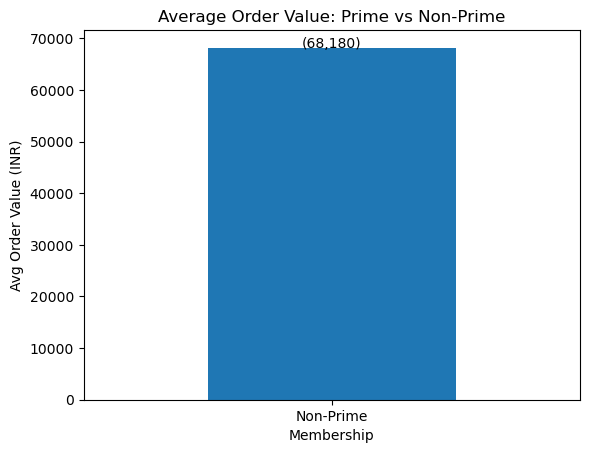

In [ ]:
import matplotlib.pyplot as plt
aov.plot(kind='bar')
plt.title("Average Order Value: Prime vs Non-Prime")
plt.xlabel("Membership")
plt.ylabel("Avg Order Value (INR)")
plt.xticks(rotation=0)
for i, v in enumerate(aov):
    plt.text(i, v, f'({int(v):,})', ha='center')

plt.show()

In [ ]:
orders_per_customer = df.groupby(['customer_id', 'is_prime_member']).size().reset_index(name='order_count')
freq = orders_per_customer.groupby('is_prime_member')['order_count'].mean()

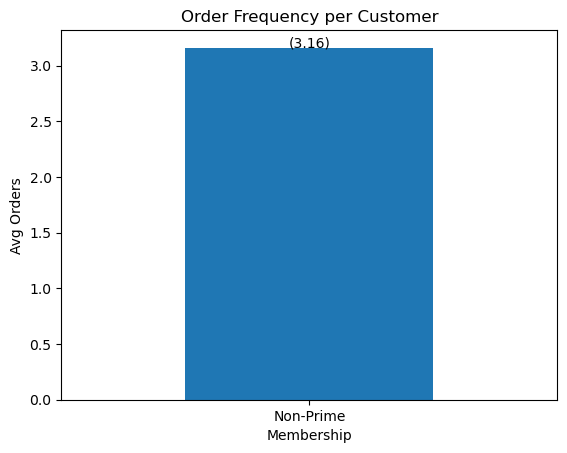

In [ ]:
freq.plot(kind='bar')
plt.title("Order Frequency per Customer")
plt.xlabel("Membership")
plt.ylabel("Avg Orders")
for i, v in enumerate(freq):
    plt.text(i, v, f'({round(v,2)})', ha='center')

plt.xticks(rotation=0)
plt.show()

In [ ]:
category_pref = df.groupby(['is_prime_member', 'category'])['final_amount_inr'].sum().reset_index()
pivot_cat = category_pref.pivot(index='category', columns='is_prime_member', values='final_amount_inr')
pivot_cat = pivot_cat.sort_values(by='Non-Prime', ascending=False).head(8)

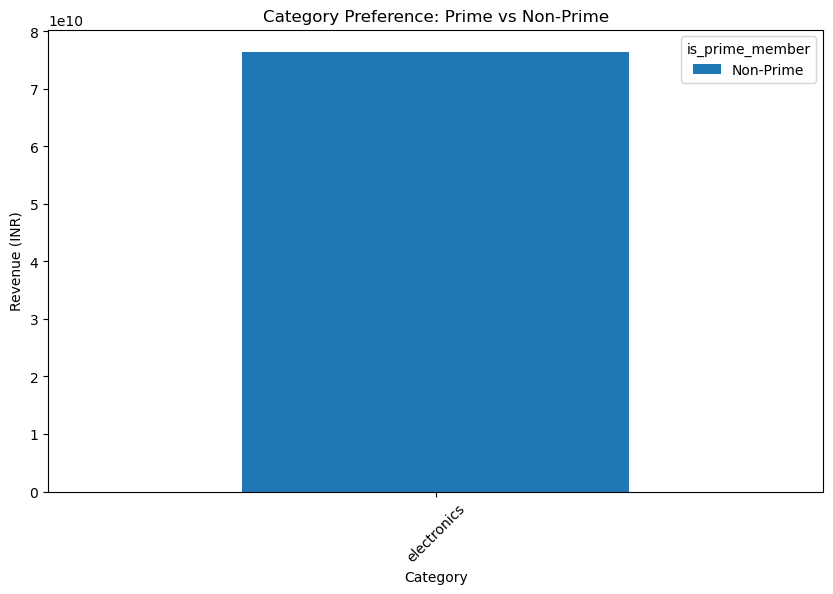

In [ ]:
pivot_cat.plot(kind='bar', figsize=(10,6))
plt.title("Category Preference: Prime vs Non-Prime")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.show()

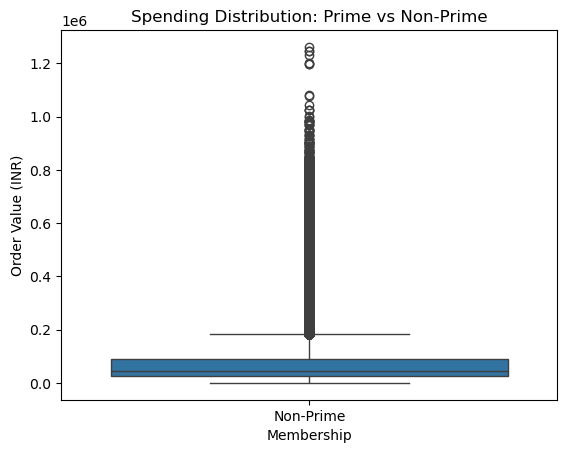

In [ ]:
import seaborn as sns

sns.boxplot(x='is_prime_member', y='final_amount_inr', data=df)

plt.title("Spending Distribution: Prime vs Non-Prime")
plt.xlabel("Membership")
plt.ylabel("Order Value (INR)")
plt.show()

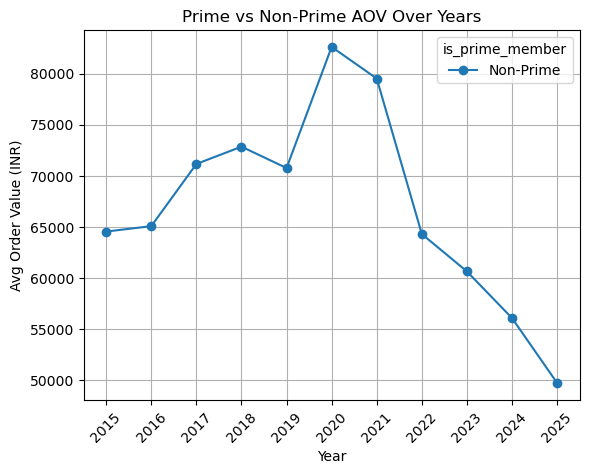

In [ ]:
prime_yearly = df.groupby(['year', 'is_prime_member'])['final_amount_inr'].mean().unstack()

prime_yearly.plot(marker='o')

plt.title("Prime vs Non-Prime AOV Over Years")
plt.xlabel("Year")
plt.ylabel("Avg Order Value (INR)")

plt.xticks(prime_yearly.index, rotation=45)
plt.grid(True)
plt.show()

EDA-7

In [ ]:
state_revenue = df.groupby('customer_state')['final_amount_inr'].sum().sort_values(ascending=False)
state_revenue.head(10)

customer_state
Maharashtra       1.745886e+10
Delhi             9.234674e+09
Tamil Nadu        7.884307e+09
Karnataka         7.638850e+09
Gujarat           7.145689e+09
Uttar Pradesh     6.758640e+09
West Bengal       5.029070e+09
Telangana         3.319918e+09
Rajasthan         2.631612e+09
Madhya Pradesh    2.203411e+09
Name: final_amount_inr, dtype: float64

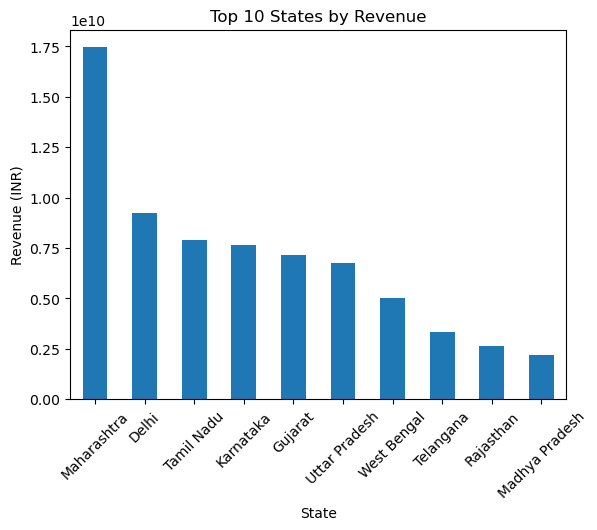

In [ ]:
import matplotlib.pyplot as plt
state_revenue.head(10).plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
tier_revenue = df.groupby('customer_tier')['final_amount_inr'].sum()
tier_revenue

customer_tier
Metro    4.220794e+10
Rural    2.312081e+09
Tier1    2.207662e+10
Tier2    9.901670e+09
Name: final_amount_inr, dtype: float64

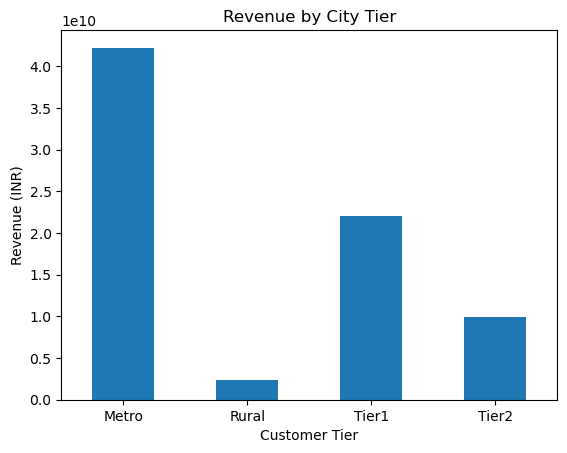

In [ ]:
tier_revenue.plot(kind='bar')

plt.title("Revenue by City Tier")
plt.xlabel("Customer Tier")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0)
plt.show()

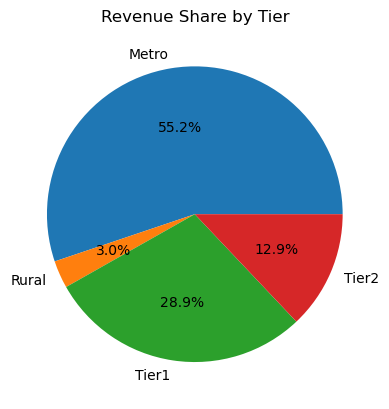

In [ ]:
tier_revenue.plot(kind='pie', autopct='%1.1f%%')

plt.title("Revenue Share by Tier")
plt.ylabel('')
plt.show()

In [ ]:
tier_yearly = df.groupby(['year', 'customer_tier'])['final_amount_inr'].sum().reset_index()

pivot_tier = tier_yearly.pivot(index='year', columns='customer_tier', values='final_amount_inr')

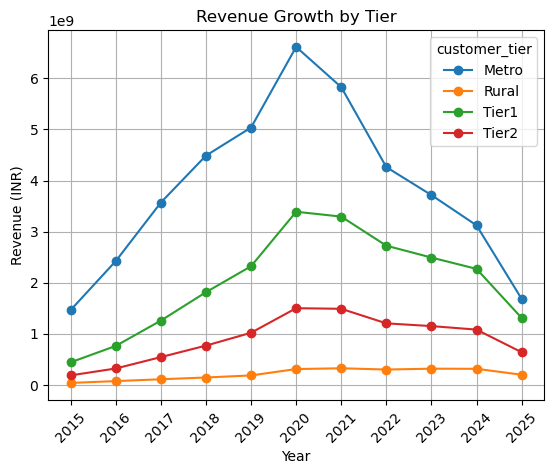

In [ ]:
pivot_tier.plot(marker='o')

plt.title("Revenue Growth by Tier")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.xticks(pivot_tier.index, rotation=45)
plt.grid(True)
plt.show()

EDA-8

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined['order_date'] = pd.to_datetime(combined['order_date'])

daily_revenue = combined.groupby('order_date')['final_amount_inr'].sum().reset_index()

In [23]:
festival_days = combined[
    combined['festival_name'] != 'No Festival'
][['order_date', 'festival_name']].drop_duplicates()

In [24]:
analysis_list = []

for _, row in festival_days.iterrows():
    date = row['order_date']
    festival = row['festival_name']
    
    temp = daily_revenue[
        (daily_revenue['order_date'] >= date - pd.Timedelta(days=7)) &
        (daily_revenue['order_date'] <= date + pd.Timedelta(days=7))
    ].copy()
    
    temp['festival'] = festival
    temp['days_from_festival'] = (temp['order_date'] - date).dt.days
    
    analysis_list.append(temp)

festival_analysis = pd.concat(analysis_list)

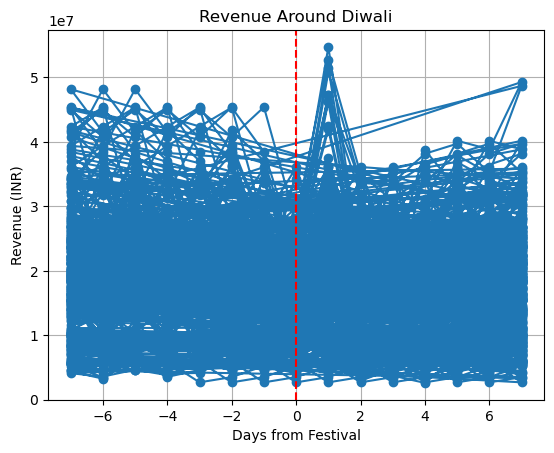

In [25]:
diwali_data = festival_analysis[
    festival_analysis['festival'] == 'Diwali Sale'
]

plt.plot(diwali_data['days_from_festival'], diwali_data['final_amount_inr'], marker='o')

plt.axvline(0, color='red', linestyle='--')

plt.title("Revenue Around Diwali")
plt.xlabel("Days from Festival")
plt.ylabel("Revenue (INR)")
plt.grid(True)
plt.show()

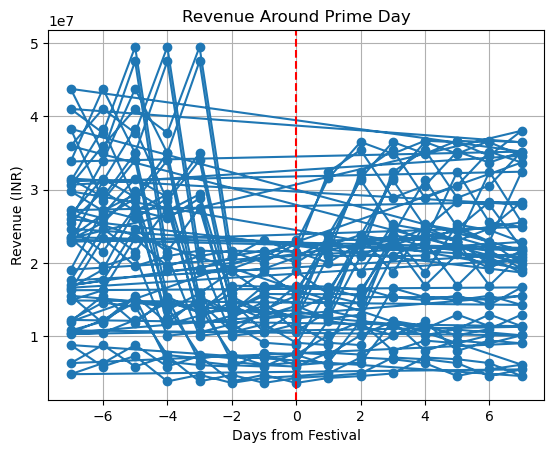

In [29]:
prime_data = festival_analysis[
    festival_analysis['festival'] == 'Prime Day'
]

plt.plot(prime_data['days_from_festival'], prime_data['final_amount_inr'], marker='o')

plt.axvline(0, color='red', linestyle='--')

plt.title("Revenue Around Prime Day")
plt.xlabel("Days from Festival")
plt.ylabel("Revenue (INR)")
plt.grid(True)
plt.show()

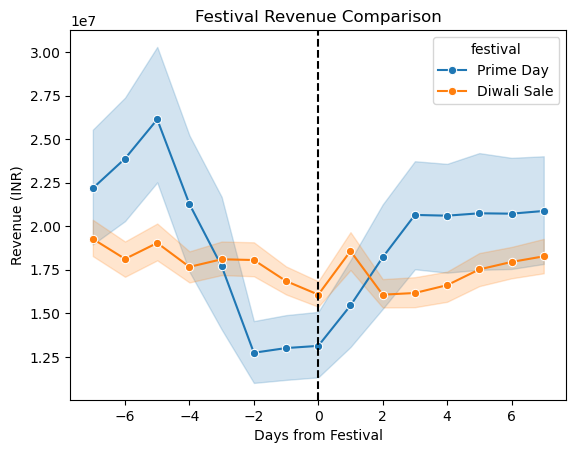

In [27]:
sns.lineplot(
    data=festival_analysis[
        festival_analysis['festival'].isin(['Diwali Sale', 'Prime Day'])
    ],
    x='days_from_festival',
    y='final_amount_inr',
    hue='festival',
    marker='o'
)

plt.axvline(0, color='black', linestyle='--')

plt.title("Festival Revenue Comparison")
plt.xlabel("Days from Festival")
plt.ylabel("Revenue (INR)")
plt.show()

EDA-9

In [30]:
combined['customer_age_group'].value_counts()

customer_age_group
26-35    480854
18-25    314849
36-45    198097
46-55     98504
55+       29695
Name: count, dtype: int64

In [31]:
age_spending = combined.groupby('customer_age_group')['final_amount_inr'].mean().sort_values(ascending=False)

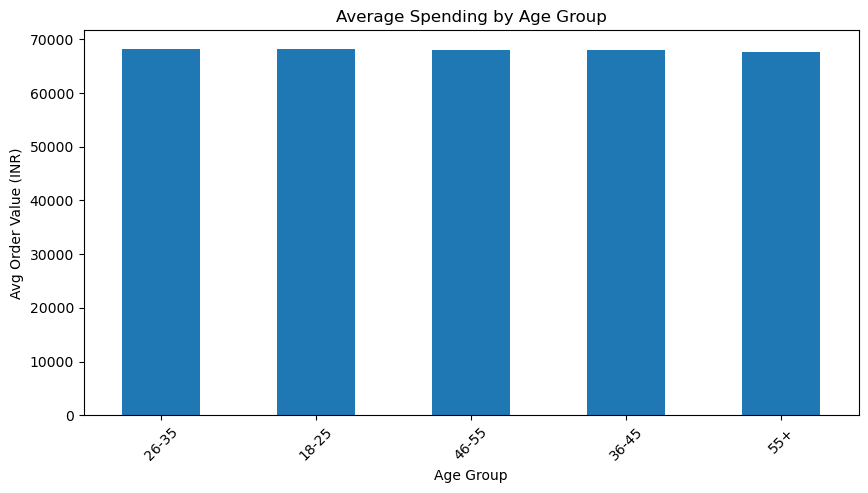

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

age_spending.plot(kind='bar')

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Avg Order Value (INR)")
plt.xticks(rotation=45)

plt.show()

In [33]:
orders_per_customer = combined.groupby(['customer_id', 'customer_age_group']).size().reset_index(name='order_count')

age_freq = orders_per_customer.groupby('customer_age_group')['order_count'].mean().sort_values(ascending=False)

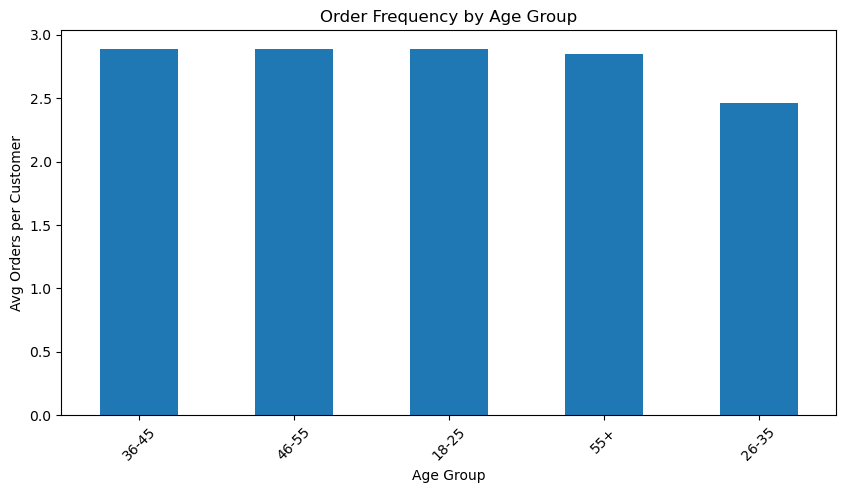

In [34]:
plt.figure(figsize=(10,5))

age_freq.plot(kind='bar')

plt.title("Order Frequency by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Avg Orders per Customer")
plt.xticks(rotation=45)

plt.show()

In [35]:
age_category = combined.groupby(['customer_age_group', 'category'])['final_amount_inr'].sum().reset_index()

pivot_age_cat = age_category.pivot(index='customer_age_group', columns='category', values='final_amount_inr')

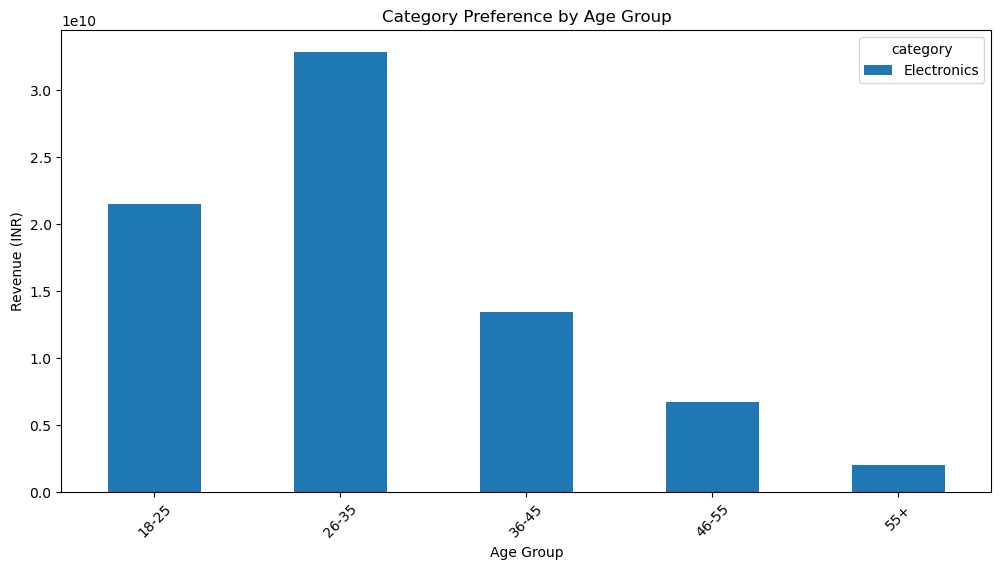

In [36]:
top_categories = combined.groupby('category')['final_amount_inr'].sum().sort_values(ascending=False).head(5).index

pivot_age_cat[top_categories].plot(kind='bar', figsize=(12,6))

plt.title("Category Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

EDA-10

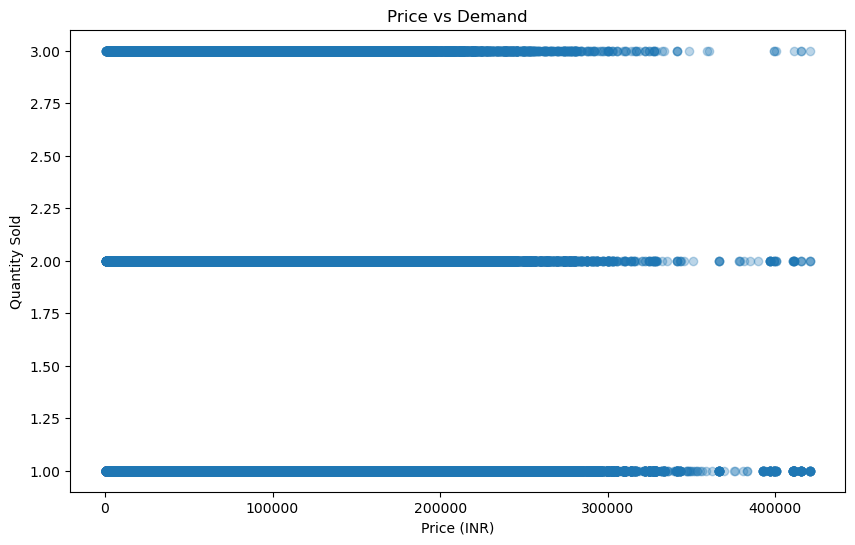

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    combined['discounted_price_inr'],
    combined['quantity'],
    alpha=0.3
)

plt.title("Price vs Demand")
plt.xlabel("Price (INR)")
plt.ylabel("Quantity Sold")

plt.show()

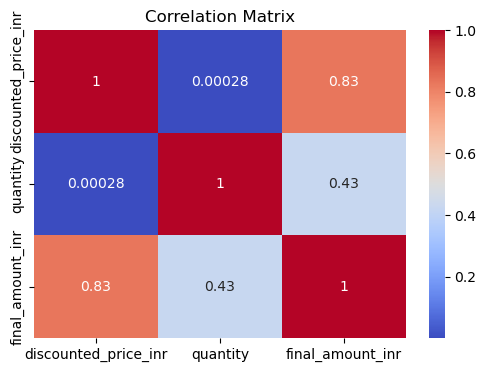

In [38]:
import seaborn as sns

corr_data = combined[['discounted_price_inr', 'quantity', 'final_amount_inr']]

corr_matrix = corr_data.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

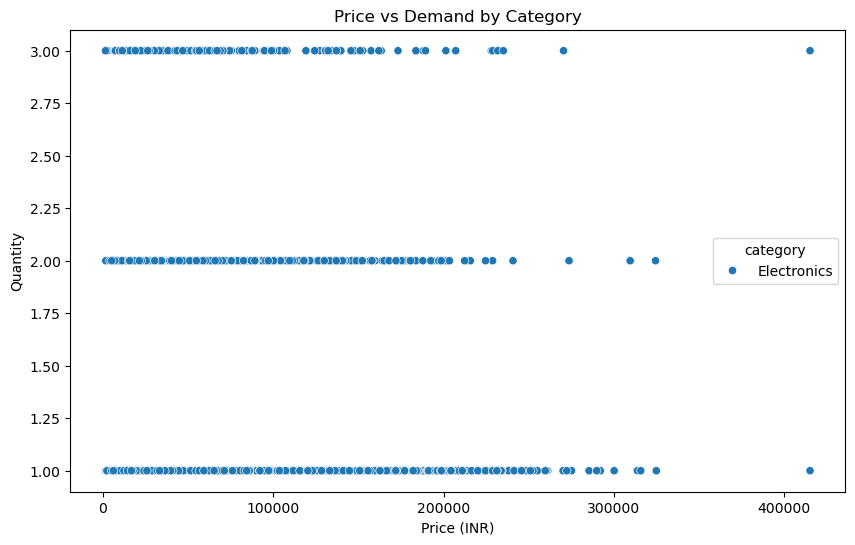

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=combined.sample(5000),  
    x='discounted_price_inr',
    y='quantity',
    hue='category'
)

plt.title("Price vs Demand by Category")
plt.xlabel("Price (INR)")
plt.ylabel("Quantity")

plt.show()

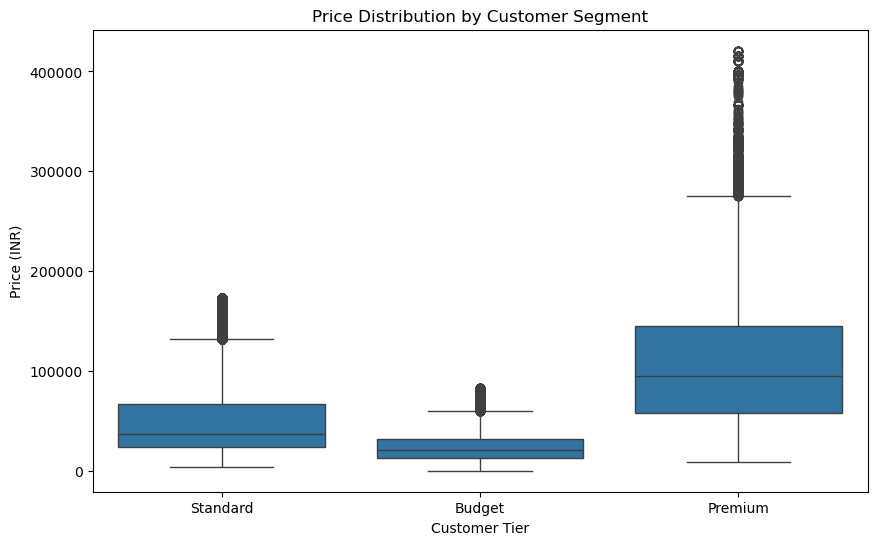

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='customer_spending_tier',
    y='discounted_price_inr',
    data=combined
)

plt.title("Price Distribution by Customer Segment")
plt.xlabel("Customer Tier")
plt.ylabel("Price (INR)")

plt.show()

EDA-11

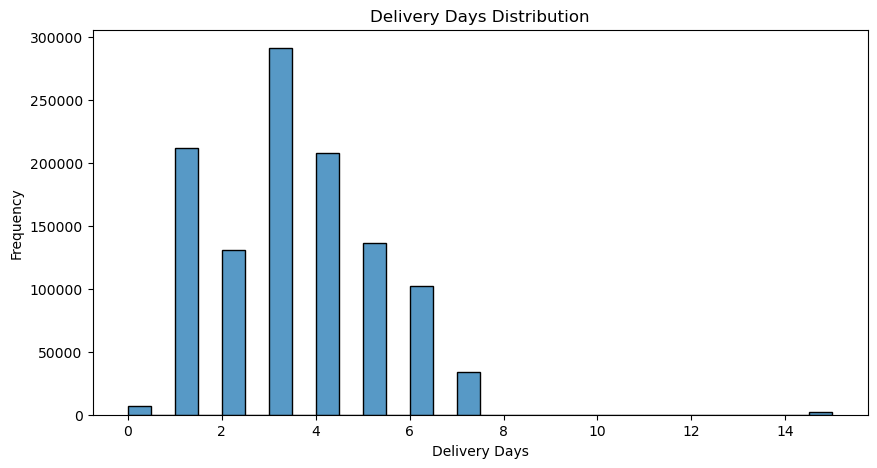

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(combined['delivery_days'], bins=30)

plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")

plt.show()

In [42]:
combined['on_time'] = combined['delivery_days'] <= 3

In [43]:
on_time_rate = combined['on_time'].value_counts(normalize=True) * 100
print(on_time_rate)

on_time
True     57.047021
False    42.952979
Name: proportion, dtype: float64


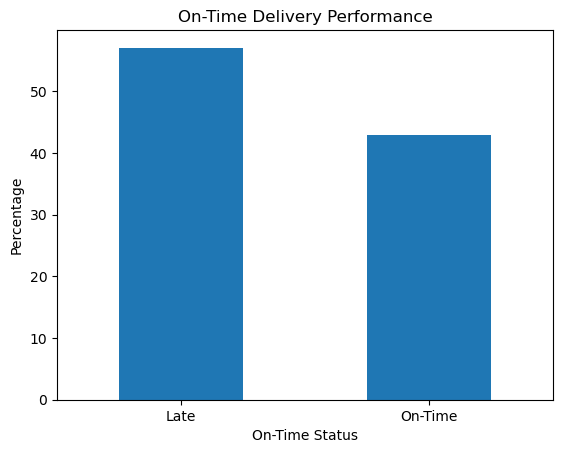

In [44]:
on_time_rate.plot(kind='bar')

plt.title("On-Time Delivery Performance")
plt.xlabel("On-Time Status")
plt.ylabel("Percentage")

plt.xticks([0,1], ['Late', 'On-Time'], rotation=0)

plt.show()

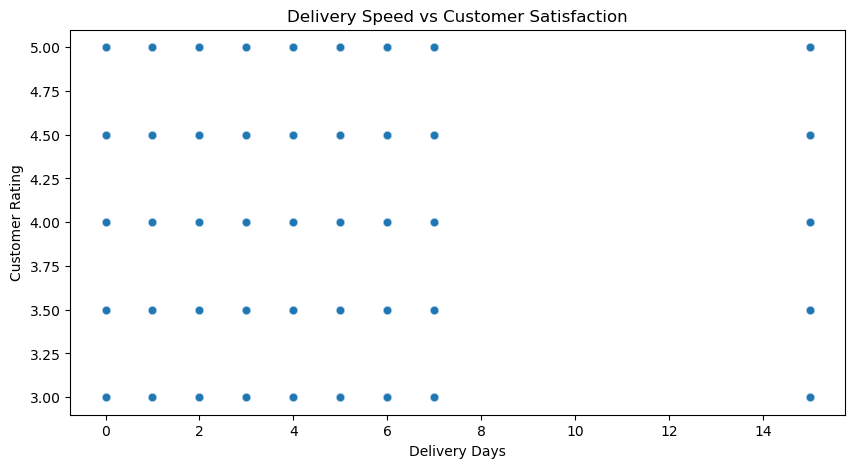

In [45]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='delivery_days',
    y='customer_rating',
    data=combined,
    alpha=0.3
)

plt.title("Delivery Speed vs Customer Satisfaction")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")

plt.show()

In [46]:
city_delivery = combined.groupby('customer_city')['delivery_days'].mean().sort_values()

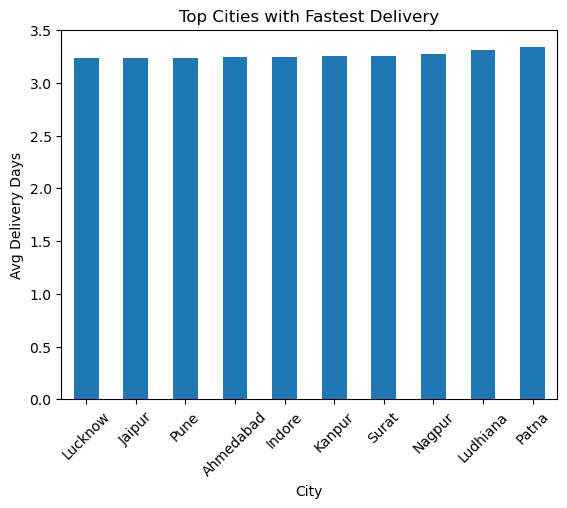

In [47]:
city_delivery.head(10).plot(kind='bar')

plt.title("Top Cities with Fastest Delivery")
plt.xlabel("City")
plt.ylabel("Avg Delivery Days")
plt.xticks(rotation=45)

plt.show()

In [48]:
tier_delivery = combined.groupby('customer_tier')['delivery_days'].mean()

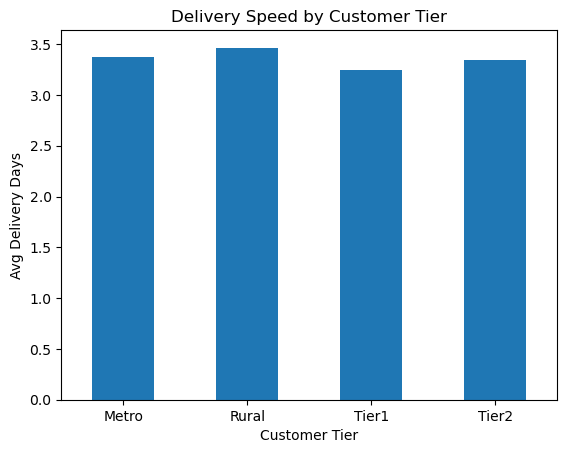

In [49]:
tier_delivery.plot(kind='bar')

plt.title("Delivery Speed by Customer Tier")
plt.xlabel("Customer Tier")
plt.ylabel("Avg Delivery Days")

plt.xticks(rotation=0)
plt.show()

EDA-12

In [50]:
combined['is_returned'] = combined['return_status'] == 'Returned'

In [51]:
return_rate = combined['is_returned'].value_counts(normalize=True) * 100
print(return_rate)

is_returned
False    92.984575
True      7.015425
Name: proportion, dtype: float64


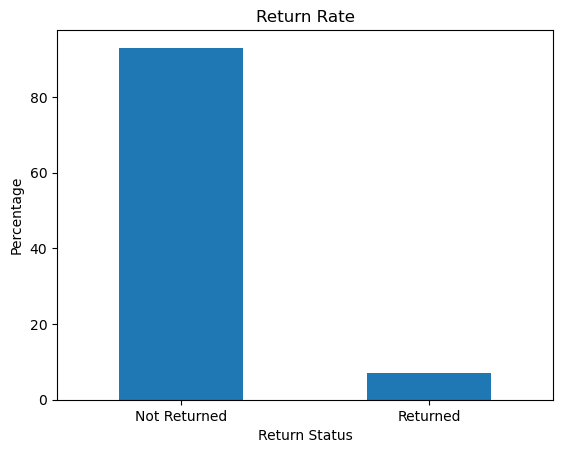

In [52]:
return_rate.plot(kind='bar')

import matplotlib.pyplot as plt

plt.title("Return Rate")
plt.xlabel("Return Status")
plt.ylabel("Percentage")

plt.xticks([0,1], ['Not Returned', 'Returned'], rotation=0)

plt.show()

In [53]:
category_returns = combined.groupby('category')['is_returned'].mean().sort_values(ascending=False)

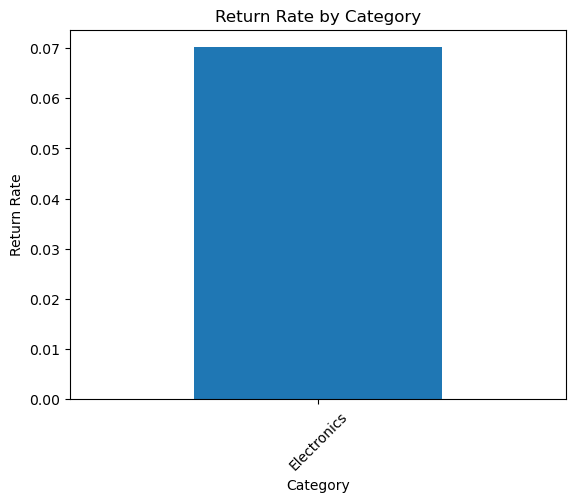

In [54]:
category_returns.head(10).plot(kind='bar')

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate")

plt.xticks(rotation=45)
plt.show()

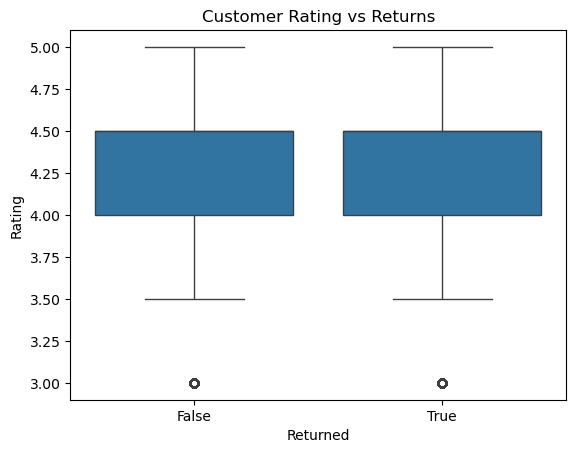

In [55]:
import seaborn as sns

sns.boxplot(
    x='is_returned',
    y='customer_rating',
    data=combined
)

plt.title("Customer Rating vs Returns")
plt.xlabel("Returned")
plt.ylabel("Rating")

plt.show()

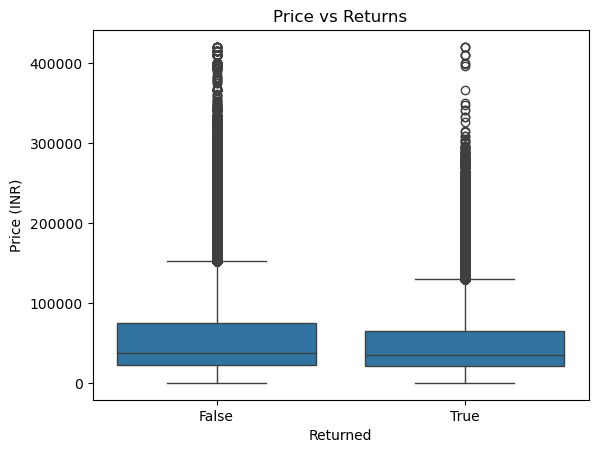

In [56]:
sns.boxplot(
    x='is_returned',
    y='discounted_price_inr',
    data=combined
)

plt.title("Price vs Returns")
plt.xlabel("Returned")
plt.ylabel("Price (INR)")

plt.show()

In [57]:
corr_data = combined[['is_returned', 'customer_rating', 'discounted_price_inr', 'product_rating']].copy()

corr_data['is_returned'] = corr_data['is_returned'].astype(int)

corr_matrix = corr_data.corr()

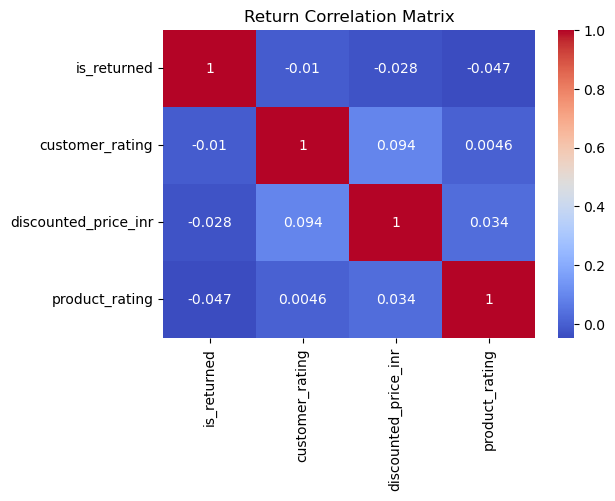

In [58]:
plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Return Correlation Matrix")
plt.show()

EDA-13

In [64]:
products = pd.read_csv("/Users/Sanjay/Desktop/GUVI/Project 2/amazon_india_products_catalog.csv")

merged = combined.merge(products, on='product_id', how='left')

In [65]:
brand_revenue = merged.groupby('brand_y')['final_amount_inr'].sum().sort_values(ascending=False)

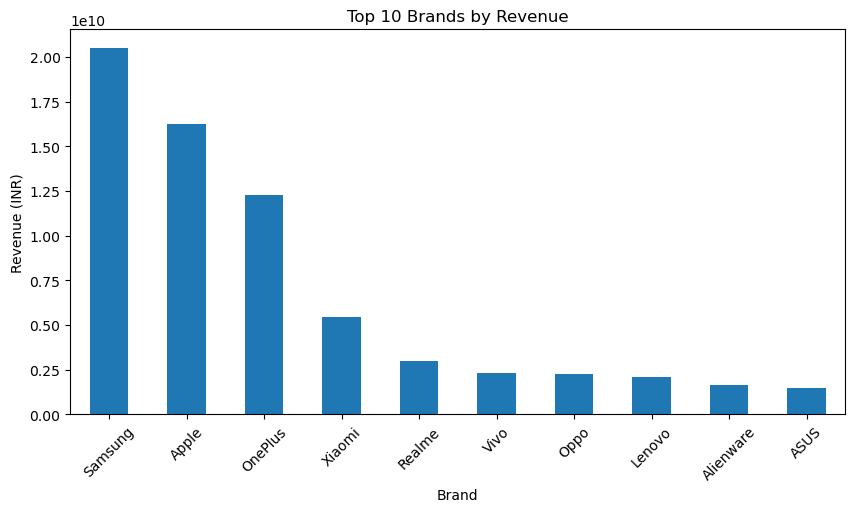

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

brand_revenue.head(10).plot(kind='bar')

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

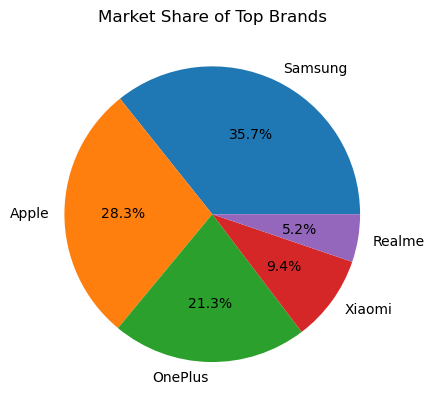

In [67]:
top_brands = brand_revenue.head(5)

top_brands.plot(kind='pie', autopct='%1.1f%%')

plt.title("Market Share of Top Brands")
plt.ylabel('')

plt.show()

In [73]:
brand_yearly = merged.groupby(['order_year', 'brand_y'])['final_amount_inr'].sum().reset_index()

pivot_brand = brand_yearly.pivot(index='order_year', columns='brand_y', values='final_amount_inr')

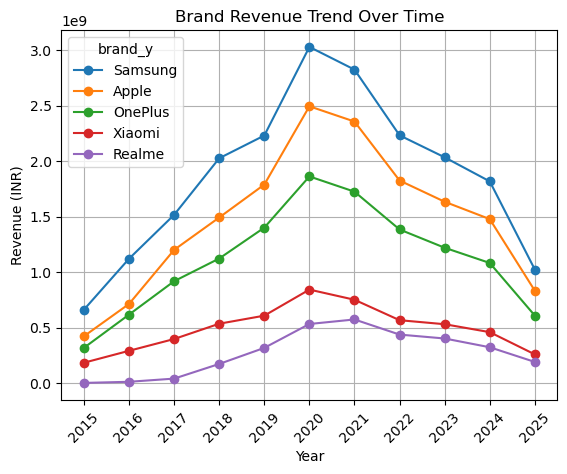

In [75]:
top5 = brand_revenue.head(5).index

pivot_brand[top5].plot(marker='o')

plt.title("Brand Revenue Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.xticks(pivot_brand.index, rotation=45)
plt.grid(True)

plt.show()

In [69]:
brand_category = merged.groupby(['category_y', 'brand_y'])['final_amount_inr'].sum().reset_index()

pivot_bc = brand_category.pivot(index='category_y', columns='brand_y', values='final_amount_inr')

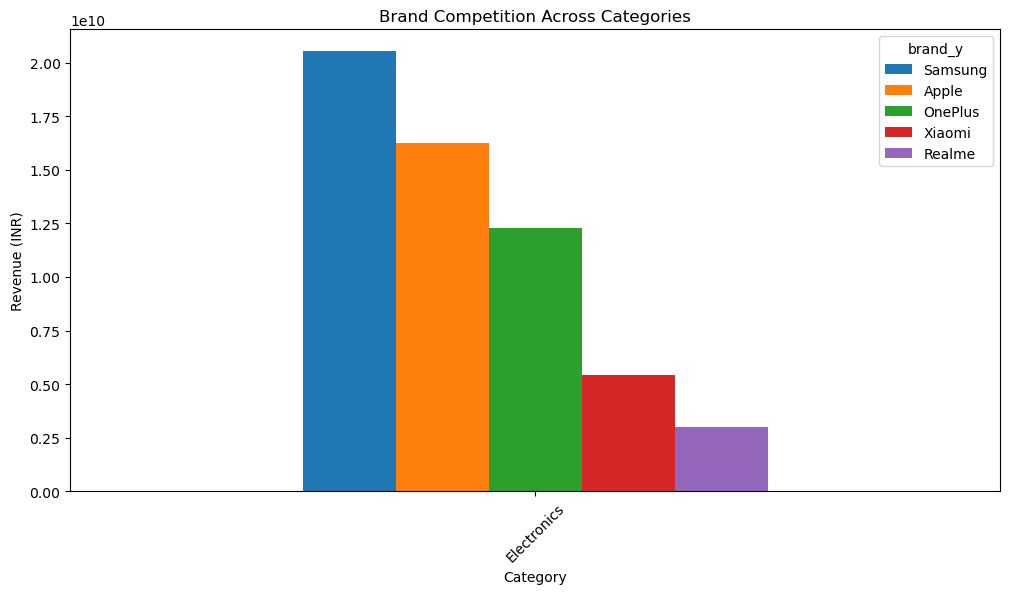

In [74]:
top5 = brand_revenue.head(5).index
pivot_bc[top5].plot(kind='bar', figsize=(12,6))

plt.title("Brand Competition Across Categories")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

In [71]:
brand_rating = merged.groupby('brand_y')['rating'].mean().sort_values(ascending=False)

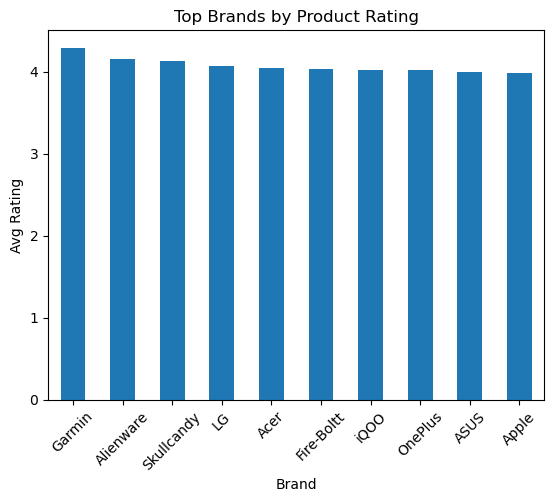

In [72]:
brand_rating.head(10).plot(kind='bar')

plt.title("Top Brands by Product Rating")
plt.xlabel("Brand")
plt.ylabel("Avg Rating")

plt.xticks(rotation=45)
plt.show()

EDA-14

In [77]:
 clv = combined.groupby('customer_id')['final_amount_inr'].sum()

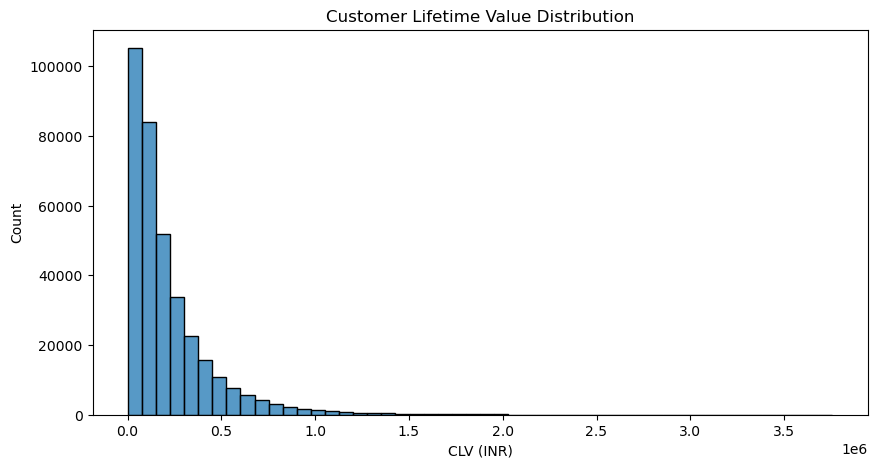

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(clv, bins=50)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV (INR)")
plt.show()

In [79]:
clv_segment = combined.groupby(['customer_spending_tier', 'customer_id'])['final_amount_inr'].sum().reset_index()

clv_segment_avg = clv_segment.groupby('customer_spending_tier')['final_amount_inr'].mean()

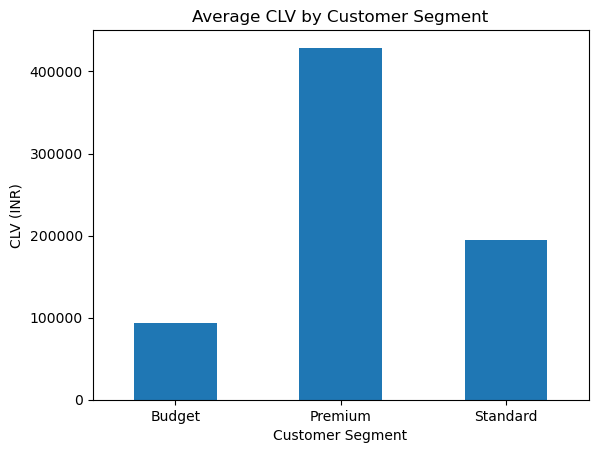

In [80]:
clv_segment_avg.plot(kind='bar')

plt.title("Average CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("CLV (INR)")

plt.xticks(rotation=0)
plt.show()

In [81]:
combined['order_date'] = pd.to_datetime(combined['order_date'])

combined['cohort_year'] = combined.groupby('customer_id')['order_date'].transform('min').dt.year
combined['order_year'] = combined['order_date'].dt.year

In [82]:
cohort_data = combined.groupby(['cohort_year', 'order_year'])['customer_id'].nunique().reset_index()

In [83]:
cohort_pivot = cohort_data.pivot(index='cohort_year', columns='order_year', values='customer_id')

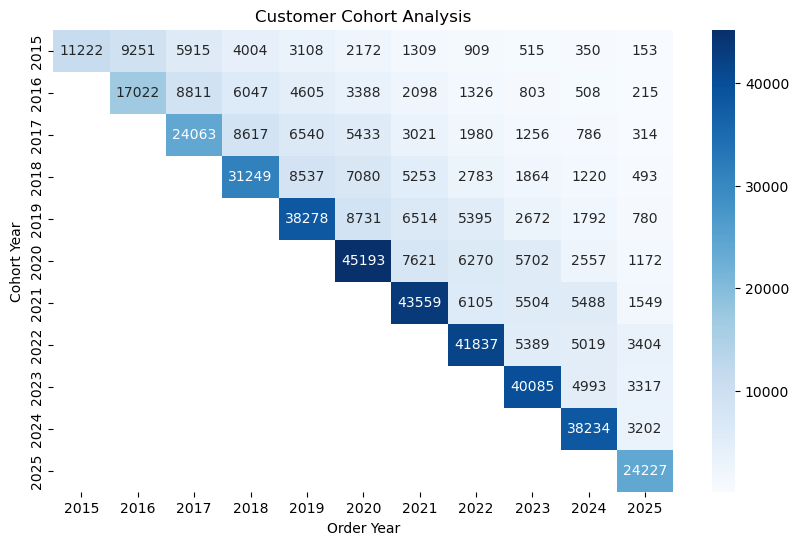

In [84]:
plt.figure(figsize=(10,6))

sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="Blues")

plt.title("Customer Cohort Analysis")
plt.xlabel("Order Year")
plt.ylabel("Cohort Year")

plt.show()

In [85]:
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0) * 100


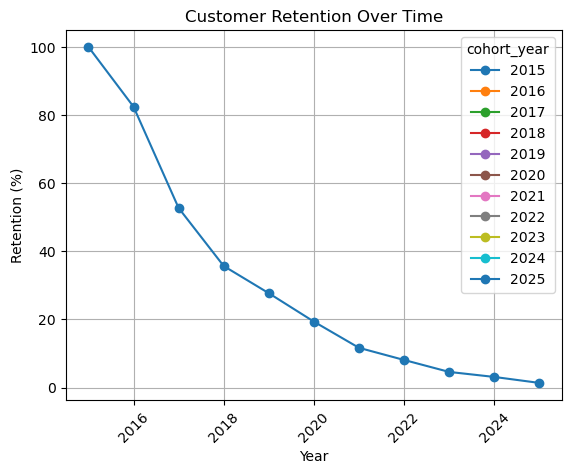

In [86]:
retention.T.plot(marker='o')

plt.title("Customer Retention Over Time")
plt.xlabel("Year")
plt.ylabel("Retention (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [87]:
clv_cohort = combined.groupby(['cohort_year', 'customer_id'])['final_amount_inr'].sum().reset_index()

clv_cohort_avg = clv_cohort.groupby('cohort_year')['final_amount_inr'].mean()

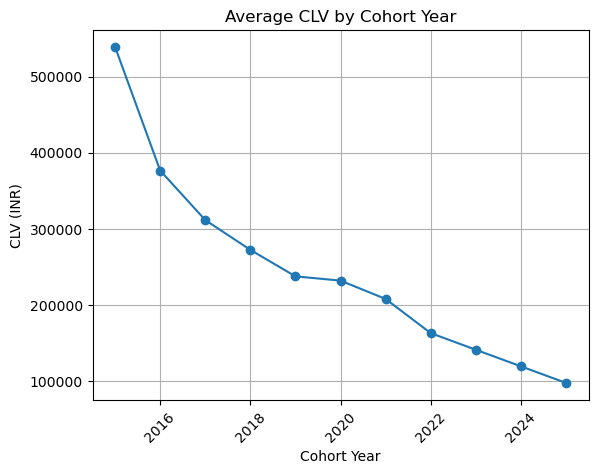

In [88]:
clv_cohort_avg.plot(marker='o')

plt.title("Average CLV by Cohort Year")
plt.xlabel("Cohort Year")
plt.ylabel("CLV (INR)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

EDA-15

In [89]:
combined[['discount_percent', 'quantity', 'final_amount_inr']].describe()

,discount_percent,quantity,final_amount_inr
count,1.121999e+06,1.121999e+06,1.121999e+06
mean,1.742266e+01,1.250036e+00,6.818037e+04
std,2.055412e+01,5.364715e-01,6.892938e+04
min,0.000000e+00,1.000000e+00,3.443300e+02
25%,0.000000e+00,1.000000e+00,2.521626e+04
50%,1.037000e+01,1.000000e+00,4.472813e+04
75%,2.842000e+01,1.000000e+00,8.851717e+04
max,7.000000e+01,3.000000e+00,1.262114e+06


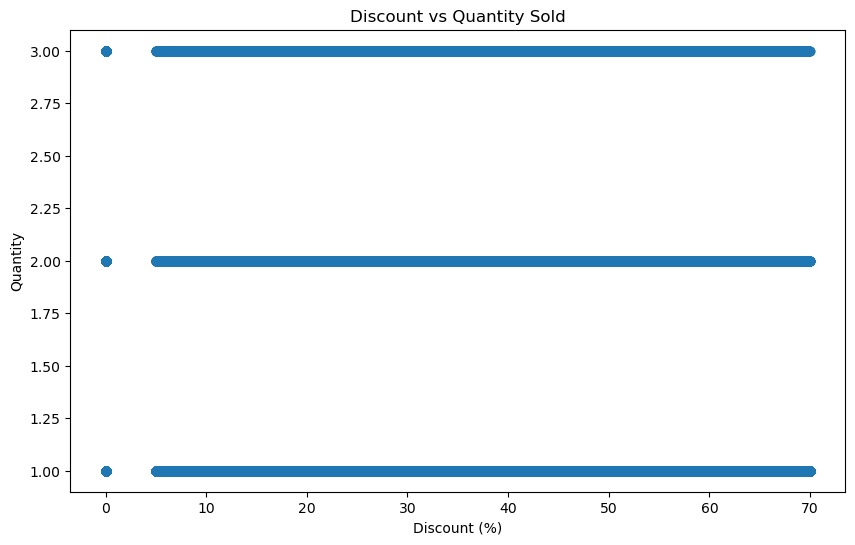

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    combined['discount_percent'],
    combined['quantity'],
    alpha=0.3
)

plt.title("Discount vs Quantity Sold")
plt.xlabel("Discount (%)")
plt.ylabel("Quantity")

plt.show()

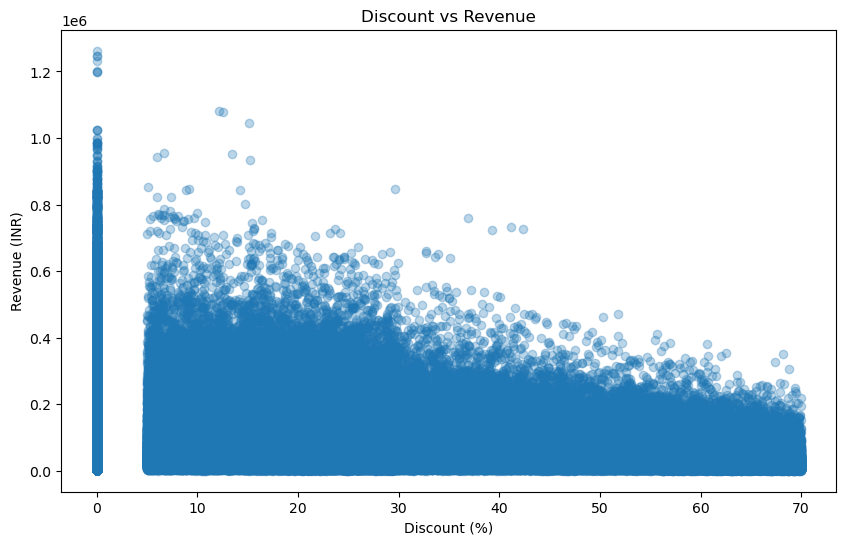

In [91]:
plt.figure(figsize=(10,6))

plt.scatter(
    combined['discount_percent'],
    combined['final_amount_inr'],
    alpha=0.3
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount (%)")
plt.ylabel("Revenue (INR)")

plt.show()

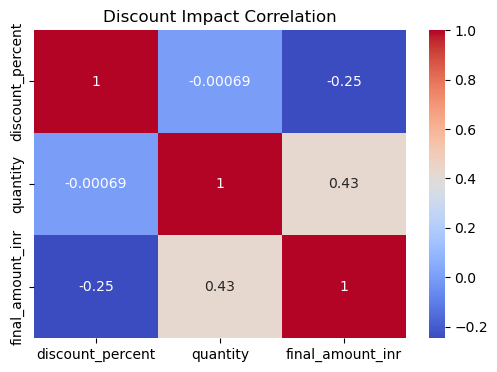

In [92]:
import seaborn as sns

corr_data = combined[['discount_percent', 'quantity', 'final_amount_inr']]

corr_matrix = corr_data.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Discount Impact Correlation")
plt.show()

In [93]:
category_discount = combined.groupby('category')[['discount_percent', 'quantity']].mean()

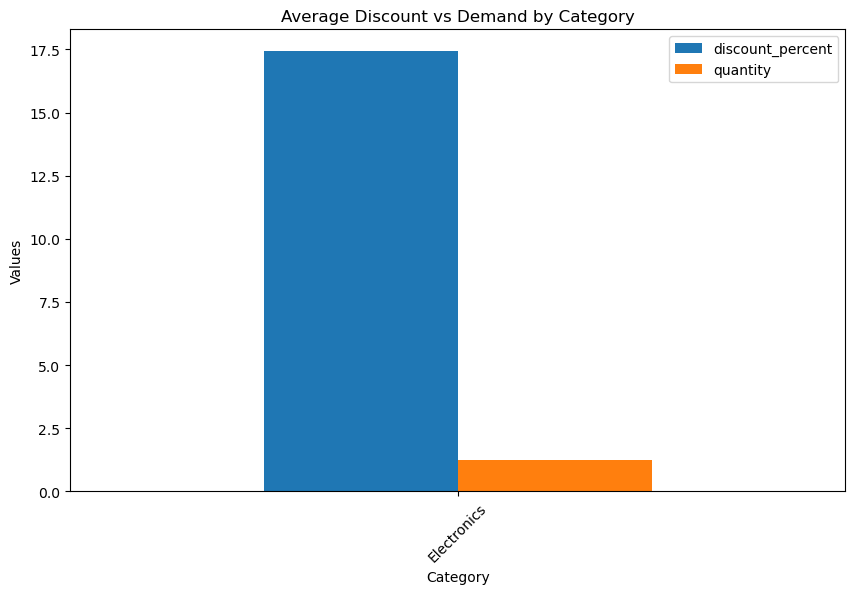

In [94]:
category_discount.plot(kind='bar', figsize=(10,6))

plt.title("Average Discount vs Demand by Category")
plt.xlabel("Category")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()

In [95]:
discount_trend = combined.groupby('order_year')[['discount_percent', 'quantity']].mean()

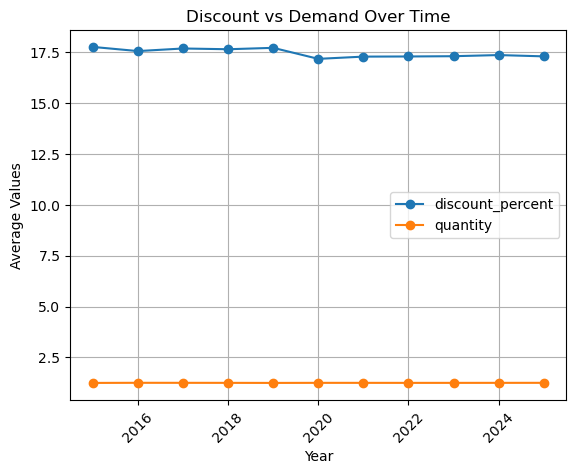

In [96]:
discount_trend.plot(marker='o')

plt.title("Discount vs Demand Over Time")
plt.xlabel("Year")
plt.ylabel("Average Values")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

EDA-16

In [97]:
merged

,transaction_id,order_date,customer_id,product_id,product_name_x,category_x,subcategory_x,brand_x,original_price_inr,discount_percent,...,product_name_y,category_y,subcategory_y,brand_y,base_price_2015,weight_kg,rating,is_prime_eligible_y,launch_year,model
0,TXN_2023_00000001,2023-01-16,CUST_2023_00005822,PROD_001899,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,59416.51,0.00,...,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,46458.94,0.06,4.2,True,2015,Watch
1,TXN_2023_00000002,2023-01-15,CUST_2019_00019403,PROD_000472,Oppo R17 Pro 64GB Black,Electronics,Smartphones,Oppo,19474.76,0.00,...,Oppo R17 Pro 64GB Black,Electronics,Smartphones,Oppo,23533.71,0.16,3.4,True,2018,R17 Pro
2,TXN_2023_00000003,2023-10-01,CUST_2023_00040022,PROD_001759,JBL Neckband,Electronics,Audio,JBL,27097.23,27.71,...,JBL Neckband,Electronics,Audio,JBL,21187.86,0.23,3.7,True,2016,Neckband
3,TXN_2023_00000004,2023-04-01,CUST_2023_00021818,PROD_001158,Xiaomi Redmi Note 12 256GB White,Electronics,Smartphones,Xiaomi,12883.85,0.00,...,Xiaomi Redmi Note 12 256GB White,Electronics,Smartphones,Xiaomi,15569.12,0.23,4.1,True,2023,Redmi Note 12
4,TXN_2023_00000005,2023-07-01,CUST_2020_00048935,PROD_000221,Apple iPhone 8 32GB Blue,Electronics,Smartphones,Apple,165637.56,0.00,...,Apple iPhone 8 32GB Blue,Electronics,Smartphones,Apple,172551.69,0.22,3.5,False,2017,iPhone 8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121994,TXN_2025_00076996,2025-01-12,CUST_2025_00020497,PROD_000262,OnePlus OnePlus 5 16GB Black,Electronics,Smartphones,OnePlus,27337.72,17.49,...,OnePlus OnePlus 5 16GB Black,Electronics,Smartphones,OnePlus,43122.15,0.20,4.6,True,2017,OnePlus 5
1121995,TXN_2025_00076997,2025-08-12,CUST_2025_00014393,PROD_000710,OnePlus OnePlus Nord 64GB Black,Electronics,Smartphones,OnePlus,28130.95,23.04,...,OnePlus OnePlus Nord 64GB Black,Electronics,Smartphones,OnePlus,44373.38,0.19,4.2,True,2020,OnePlus Nord
1121996,TXN_2025_00076998,2025-12-31,CUST_2021_00023963,PROD_001476,Realme Realme 13 128GB Blue,Electronics,Smartphones,Realme,26769.50,0.00,...,Realme Realme 13 128GB Blue,Electronics,Smartphones,Realme,42225.85,0.21,3.5,True,2025,Realme 13
1121997,TXN_2025_00076999,2025-12-12,CUST_2025_00019394,PROD_001739,Realme iPad 4GB RAM Silver,Electronics,Tablets,Realme,133854.95,0.00,...,Realme iPad 4GB RAM Silver,Electronics,Tablets,Realme,63342.29,0.51,4.5,True,2021,iPad


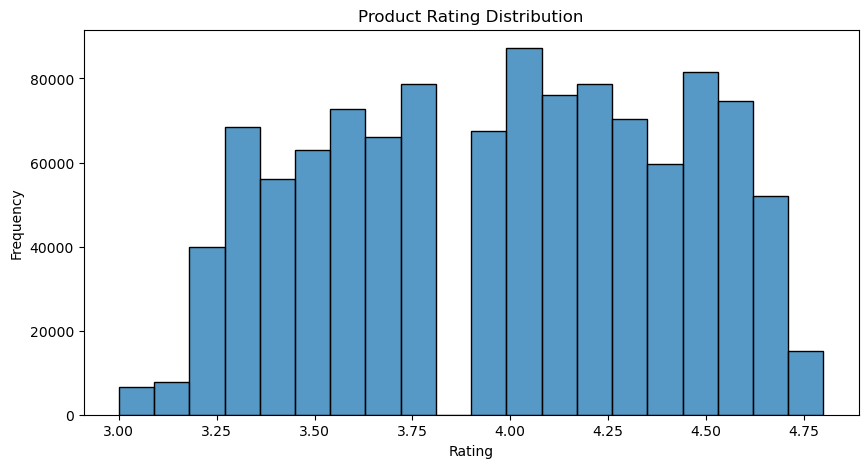

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(merged['rating'], bins=20)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

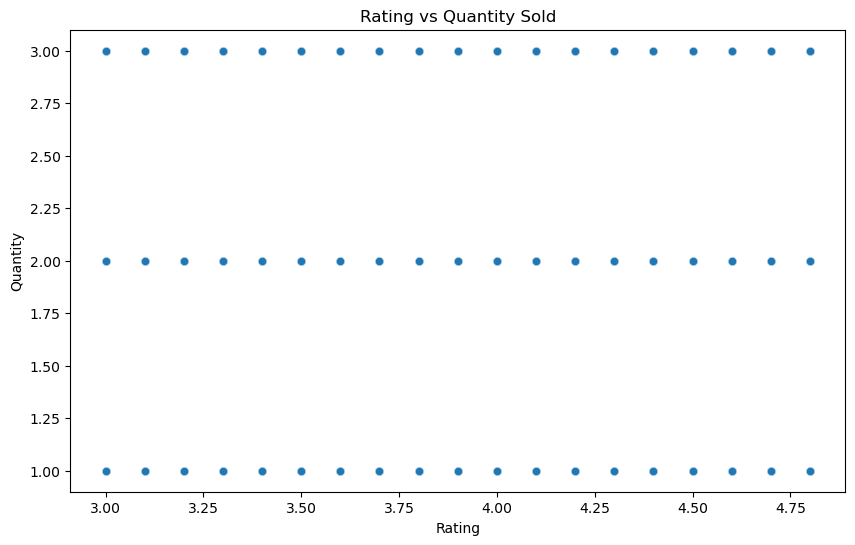

In [99]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='rating',
    y='quantity',
    data=merged,
    alpha=0.3
)

plt.title("Rating vs Quantity Sold")
plt.xlabel("Rating")
plt.ylabel("Quantity")

plt.show()

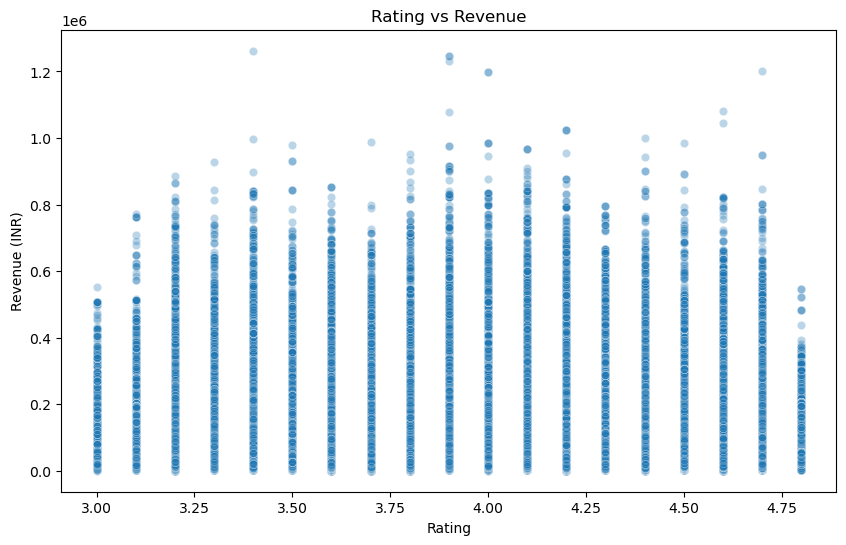

In [100]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='rating',
    y='final_amount_inr',
    data=merged,
    alpha=0.3
)

plt.title("Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue (INR)")

plt.show()

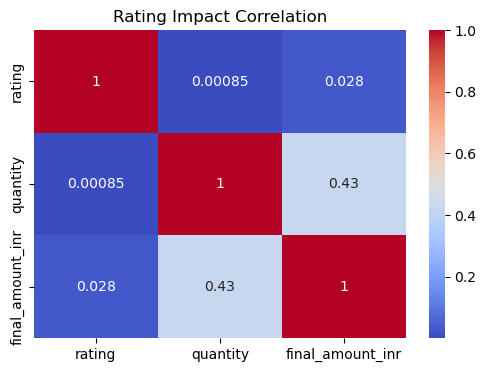

In [101]:
corr_data = merged[['rating', 'quantity', 'final_amount_inr']]

corr_matrix = corr_data.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Rating Impact Correlation")
plt.show()

In [102]:
category_rating = merged.groupby('category_y')[['rating', 'quantity']].mean()

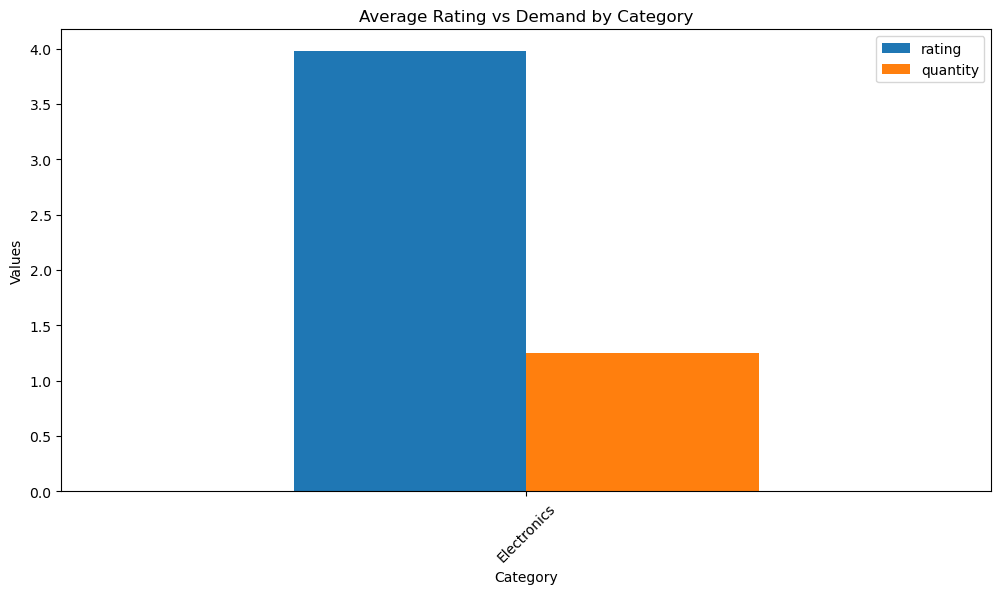

In [103]:
category_rating.plot(kind='bar', figsize=(12,6))

plt.title("Average Rating vs Demand by Category")
plt.xlabel("Category")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.show()

In [104]:
merged['price_range'] = pd.cut(
    merged['discounted_price_inr'],
    bins=[0, 500, 2000, 5000, 20000],
    labels=['Low', 'Mid', 'High', 'Premium']
)

/var/folders/8f/6_l0xx0x2s7gs572hcv0rpsh0000gp/T/ipykernel_1485/3127267302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = merged.groupby('price_range')['rating'].mean()


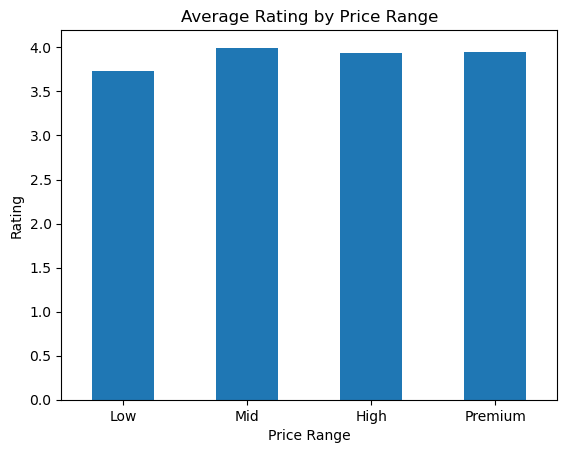

In [105]:
price_rating = merged.groupby('price_range')['rating'].mean()

price_rating.plot(kind='bar')

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Rating")

plt.xticks(rotation=0)
plt.show()

EDA-17

In [106]:
customer_orders = combined.groupby('customer_id').size()

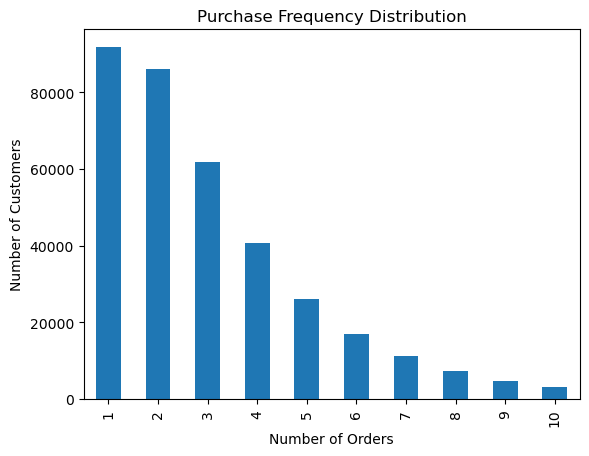

In [107]:
import matplotlib.pyplot as plt

customer_orders.value_counts().head(10).plot(kind='bar')

plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

In [108]:
rfm['segment'].value_counts()

segment
Potential Loyalists    101495
Loyal Customers         65392
At Risk                 62438
Lost Customers          44843
Champions               41032
New Customers           39769
Name: count, dtype: int64

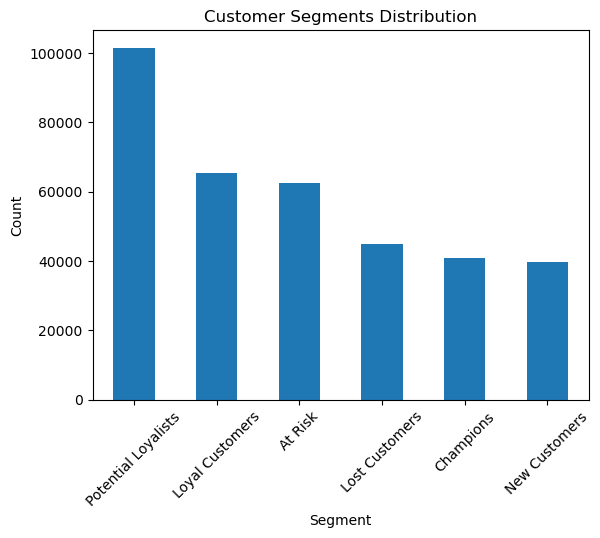

In [109]:
rfm['segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [110]:
combined = combined.sort_values(by=['customer_id', 'order_date'])

In [111]:
combined['next_category'] = combined.groupby('customer_id')['category'].shift(-1)

In [112]:
transition = combined.groupby(['category', 'next_category']).size().unstack().fillna(0)

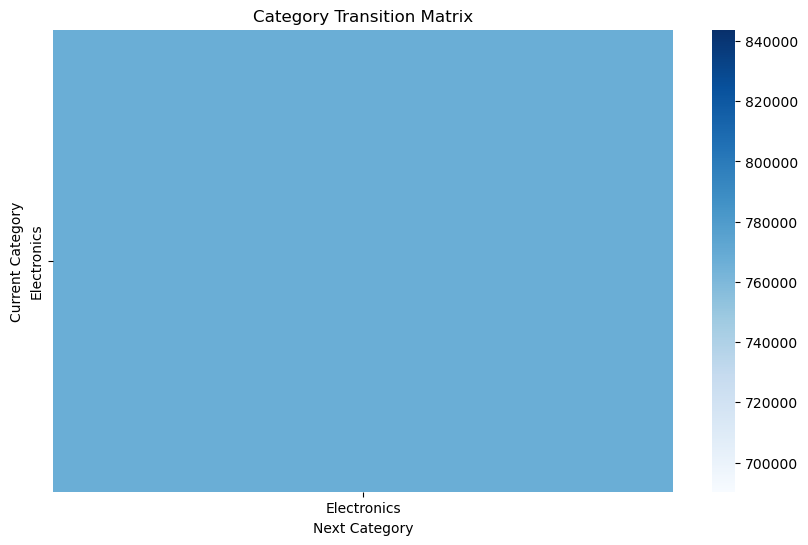

In [113]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(transition, cmap='Blues')

plt.title("Category Transition Matrix")
plt.xlabel("Next Category")
plt.ylabel("Current Category")

plt.show()

In [114]:
top_transitions = combined.groupby(['category', 'next_category']).size().reset_index(name='count')

top_transitions = top_transitions.sort_values(by='count', ascending=False).head(10)

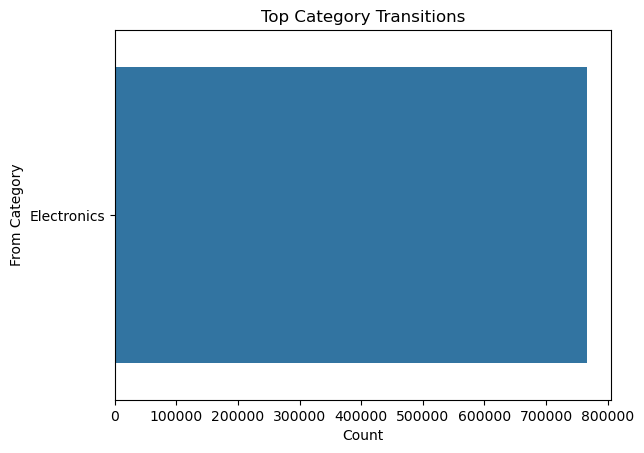

In [115]:
sns.barplot(
    data=top_transitions,
    x='count',
    y='category'
)

plt.title("Top Category Transitions")
plt.xlabel("Count")
plt.ylabel("From Category")

plt.show()

EDA-18

In [116]:
merged


,transaction_id,order_date,customer_id,product_id,product_name_x,category_x,subcategory_x,brand_x,original_price_inr,discount_percent,...,category_y,subcategory_y,brand_y,base_price_2015,weight_kg,rating,is_prime_eligible_y,launch_year,model,price_range
0,TXN_2023_00000001,2023-01-16,CUST_2023_00005822,PROD_001899,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,59416.51,0.00,...,Electronics,Smart Watch,Xiaomi,46458.94,0.06,4.2,True,2015,Watch,NaN
1,TXN_2023_00000002,2023-01-15,CUST_2019_00019403,PROD_000472,Oppo R17 Pro 64GB Black,Electronics,Smartphones,Oppo,19474.76,0.00,...,Electronics,Smartphones,Oppo,23533.71,0.16,3.4,True,2018,R17 Pro,Premium
2,TXN_2023_00000003,2023-10-01,CUST_2023_00040022,PROD_001759,JBL Neckband,Electronics,Audio,JBL,27097.23,27.71,...,Electronics,Audio,JBL,21187.86,0.23,3.7,True,2016,Neckband,Premium
3,TXN_2023_00000004,2023-04-01,CUST_2023_00021818,PROD_001158,Xiaomi Redmi Note 12 256GB White,Electronics,Smartphones,Xiaomi,12883.85,0.00,...,Electronics,Smartphones,Xiaomi,15569.12,0.23,4.1,True,2023,Redmi Note 12,Premium
4,TXN_2023_00000005,2023-07-01,CUST_2020_00048935,PROD_000221,Apple iPhone 8 32GB Blue,Electronics,Smartphones,Apple,165637.56,0.00,...,Electronics,Smartphones,Apple,172551.69,0.22,3.5,False,2017,iPhone 8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121994,TXN_2025_00076996,2025-01-12,CUST_2025_00020497,PROD_000262,OnePlus OnePlus 5 16GB Black,Electronics,Smartphones,OnePlus,27337.72,17.49,...,Electronics,Smartphones,OnePlus,43122.15,0.20,4.6,True,2017,OnePlus 5,NaN
1121995,TXN_2025_00076997,2025-08-12,CUST_2025_00014393,PROD_000710,OnePlus OnePlus Nord 64GB Black,Electronics,Smartphones,OnePlus,28130.95,23.04,...,Electronics,Smartphones,OnePlus,44373.38,0.19,4.2,True,2020,OnePlus Nord,NaN
1121996,TXN_2025_00076998,2025-12-31,CUST_2021_00023963,PROD_001476,Realme Realme 13 128GB Blue,Electronics,Smartphones,Realme,26769.50,0.00,...,Electronics,Smartphones,Realme,42225.85,0.21,3.5,True,2025,Realme 13,NaN
1121997,TXN_2025_00076999,2025-12-12,CUST_2025_00019394,PROD_001739,Realme iPad 4GB RAM Silver,Electronics,Tablets,Realme,133854.95,0.00,...,Electronics,Tablets,Realme,63342.29,0.51,4.5,True,2021,iPad,NaN


In [117]:
launch_perf = merged.groupby('launch_year')['final_amount_inr'].sum().sort_values()

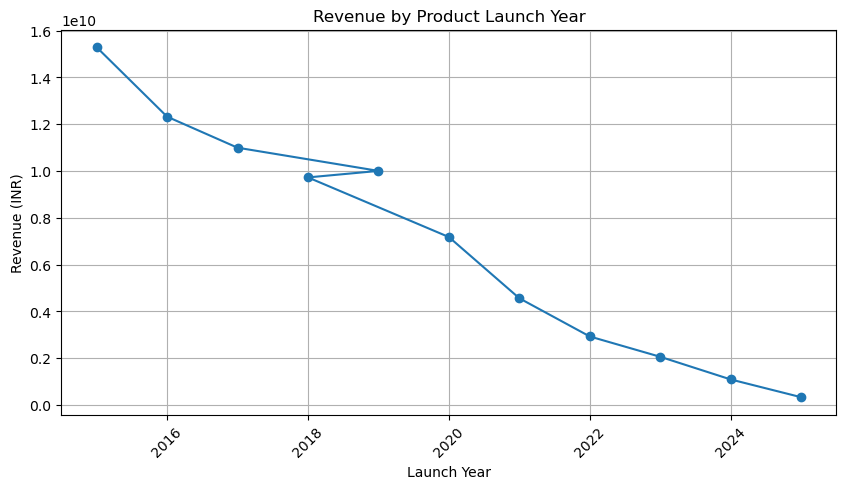

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

launch_perf.plot(marker='o')

plt.title("Revenue by Product Launch Year")
plt.xlabel("Launch Year")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [119]:
product_trend = merged.groupby(['order_year', 'product_id'])['final_amount_inr'].sum().reset_index()

In [120]:
top_products = merged.groupby('product_id')['final_amount_inr'].sum().sort_values(ascending=False).head(5).index

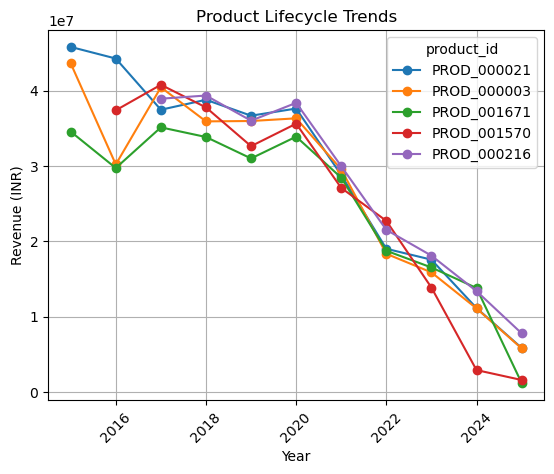

In [121]:
pivot_product = product_trend.pivot(index='order_year', columns='product_id', values='final_amount_inr')

pivot_product[top_products].plot(marker='o')

plt.title("Product Lifecycle Trends")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [122]:
category_yearly = merged.groupby(['order_year', 'category_y'])['final_amount_inr'].sum().reset_index()

pivot_category = category_yearly.pivot(index='order_year', columns='category_y', values='final_amount_inr')

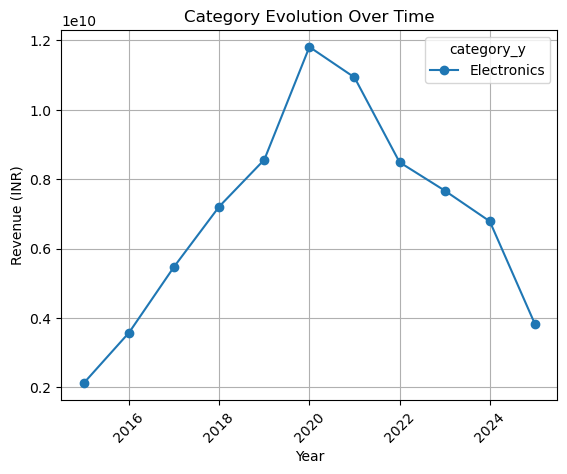

In [123]:
top_categories = merged.groupby('category_y')['final_amount_inr'].sum().sort_values(ascending=False).head(5).index

pivot_category[top_categories].plot(marker='o')

plt.title("Category Evolution Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [124]:
merged['product_age'] = merged['order_year'] - merged['launch_year']

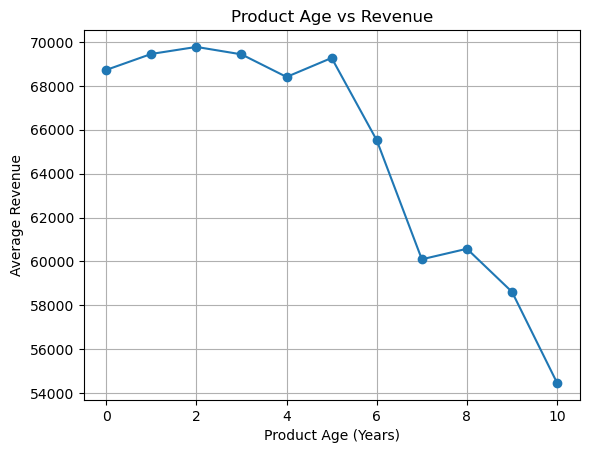

In [125]:
age_perf = merged.groupby('product_age')['final_amount_inr'].mean()

age_perf.plot(marker='o')

plt.title("Product Age vs Revenue")
plt.xlabel("Product Age (Years)")
plt.ylabel("Average Revenue")

plt.grid(True)
plt.show()

EDA-19

In [126]:
merged

,transaction_id,order_date,customer_id,product_id,product_name_x,category_x,subcategory_x,brand_x,original_price_inr,discount_percent,...,subcategory_y,brand_y,base_price_2015,weight_kg,rating,is_prime_eligible_y,launch_year,model,price_range,product_age
0,TXN_2023_00000001,2023-01-16,CUST_2023_00005822,PROD_001899,Xiaomi Watch Premium,Electronics,Smart Watch,Xiaomi,59416.51,0.00,...,Smart Watch,Xiaomi,46458.94,0.06,4.2,True,2015,Watch,NaN,8
1,TXN_2023_00000002,2023-01-15,CUST_2019_00019403,PROD_000472,Oppo R17 Pro 64GB Black,Electronics,Smartphones,Oppo,19474.76,0.00,...,Smartphones,Oppo,23533.71,0.16,3.4,True,2018,R17 Pro,Premium,5
2,TXN_2023_00000003,2023-10-01,CUST_2023_00040022,PROD_001759,JBL Neckband,Electronics,Audio,JBL,27097.23,27.71,...,Audio,JBL,21187.86,0.23,3.7,True,2016,Neckband,Premium,7
3,TXN_2023_00000004,2023-04-01,CUST_2023_00021818,PROD_001158,Xiaomi Redmi Note 12 256GB White,Electronics,Smartphones,Xiaomi,12883.85,0.00,...,Smartphones,Xiaomi,15569.12,0.23,4.1,True,2023,Redmi Note 12,Premium,0
4,TXN_2023_00000005,2023-07-01,CUST_2020_00048935,PROD_000221,Apple iPhone 8 32GB Blue,Electronics,Smartphones,Apple,165637.56,0.00,...,Smartphones,Apple,172551.69,0.22,3.5,False,2017,iPhone 8,NaN,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121994,TXN_2025_00076996,2025-01-12,CUST_2025_00020497,PROD_000262,OnePlus OnePlus 5 16GB Black,Electronics,Smartphones,OnePlus,27337.72,17.49,...,Smartphones,OnePlus,43122.15,0.20,4.6,True,2017,OnePlus 5,NaN,8
1121995,TXN_2025_00076997,2025-08-12,CUST_2025_00014393,PROD_000710,OnePlus OnePlus Nord 64GB Black,Electronics,Smartphones,OnePlus,28130.95,23.04,...,Smartphones,OnePlus,44373.38,0.19,4.2,True,2020,OnePlus Nord,NaN,5
1121996,TXN_2025_00076998,2025-12-31,CUST_2021_00023963,PROD_001476,Realme Realme 13 128GB Blue,Electronics,Smartphones,Realme,26769.50,0.00,...,Smartphones,Realme,42225.85,0.21,3.5,True,2025,Realme 13,NaN,0
1121997,TXN_2025_00076999,2025-12-12,CUST_2025_00019394,PROD_001739,Realme iPad 4GB RAM Silver,Electronics,Tablets,Realme,133854.95,0.00,...,Tablets,Realme,63342.29,0.51,4.5,True,2021,iPad,NaN,4


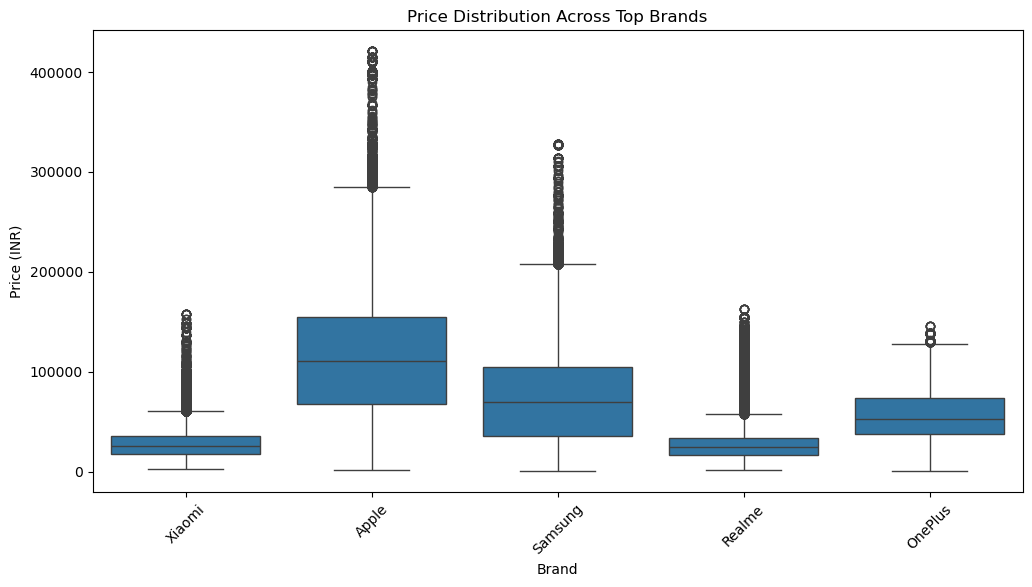

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

top_brands = merged.groupby('brand_y')['final_amount_inr'].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged[merged['brand_y'].isin(top_brands)],
    x='brand_y',
    y='discounted_price_inr'
)

plt.title("Price Distribution Across Top Brands")
plt.xlabel("Brand")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)

plt.show()

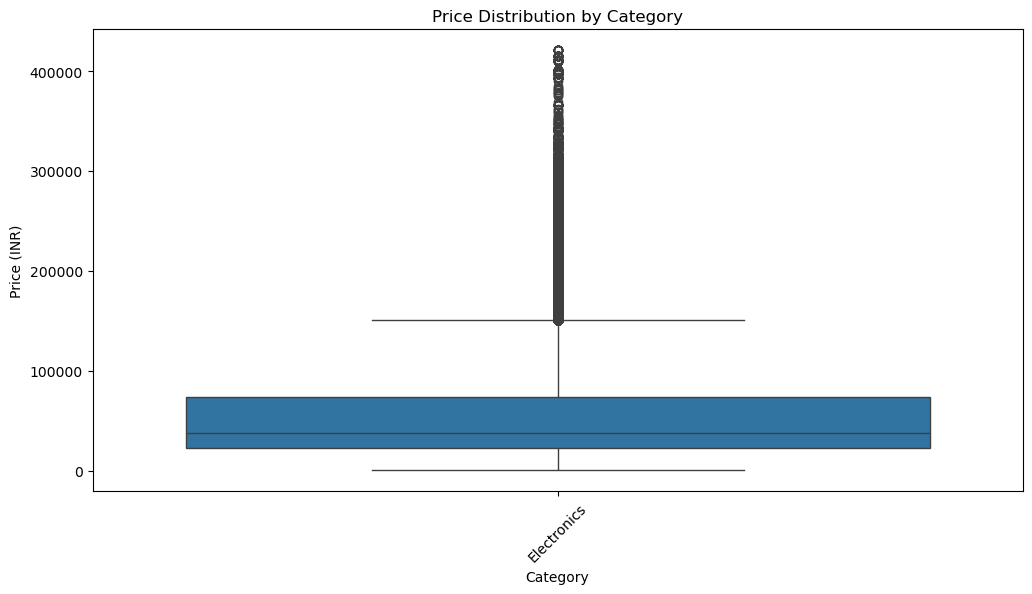

In [128]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='category_y',
    y='discounted_price_inr'
)

plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)

plt.show()

In [129]:
brand_metrics = merged.groupby('brand_y').agg({
    'discounted_price_inr': 'mean',
    'quantity': 'mean'
}).reset_index()

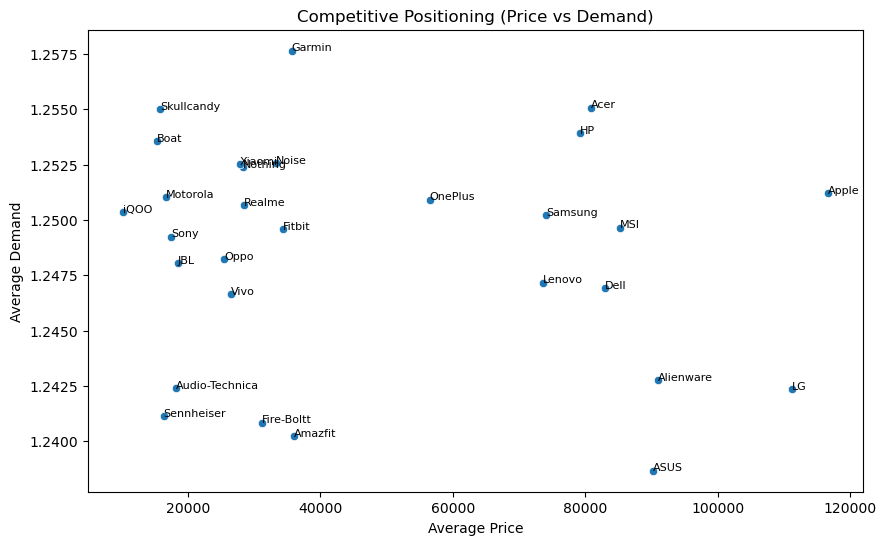

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_metrics,
    x='discounted_price_inr',
    y='quantity'
)

for i, row in brand_metrics.iterrows():
    plt.text(row['discounted_price_inr'], row['quantity'], row['brand_y'], fontsize=8)

plt.title("Competitive Positioning (Price vs Demand)")
plt.xlabel("Average Price")
plt.ylabel("Average Demand")

plt.show()

In [131]:
brand_market = merged.groupby('brand_y').agg({
    'final_amount_inr': 'sum',
    'discounted_price_inr': 'mean'
}).reset_index()

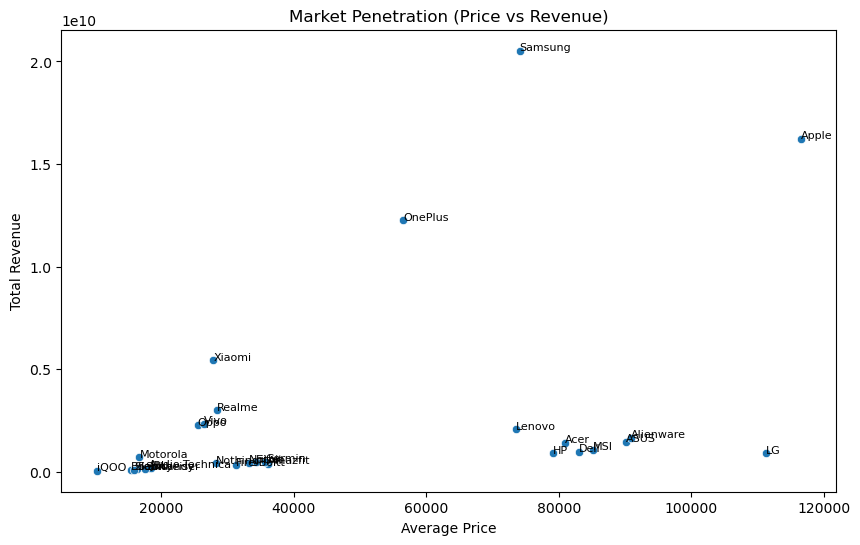

In [132]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=brand_market,
    x='discounted_price_inr',
    y='final_amount_inr'
)

for i, row in brand_market.iterrows():
    plt.text(row['discounted_price_inr'], row['final_amount_inr'], row['brand_y'], fontsize=8)

plt.title("Market Penetration (Price vs Revenue)")
plt.xlabel("Average Price")
plt.ylabel("Total Revenue")

plt.show()

EDA-20

In [133]:
revenue_trend = combined.groupby('order_year')['final_amount_inr'].sum()

In [134]:
new_customers = combined.groupby('order_year')['customer_id'].nunique()

In [135]:
customer_year = combined.groupby(['customer_id', 'order_year']).size().reset_index()

retention = customer_year.groupby('order_year')['customer_id'].nunique()

In [136]:
delivery_eff = combined.groupby('order_year')['delivery_days'].mean()

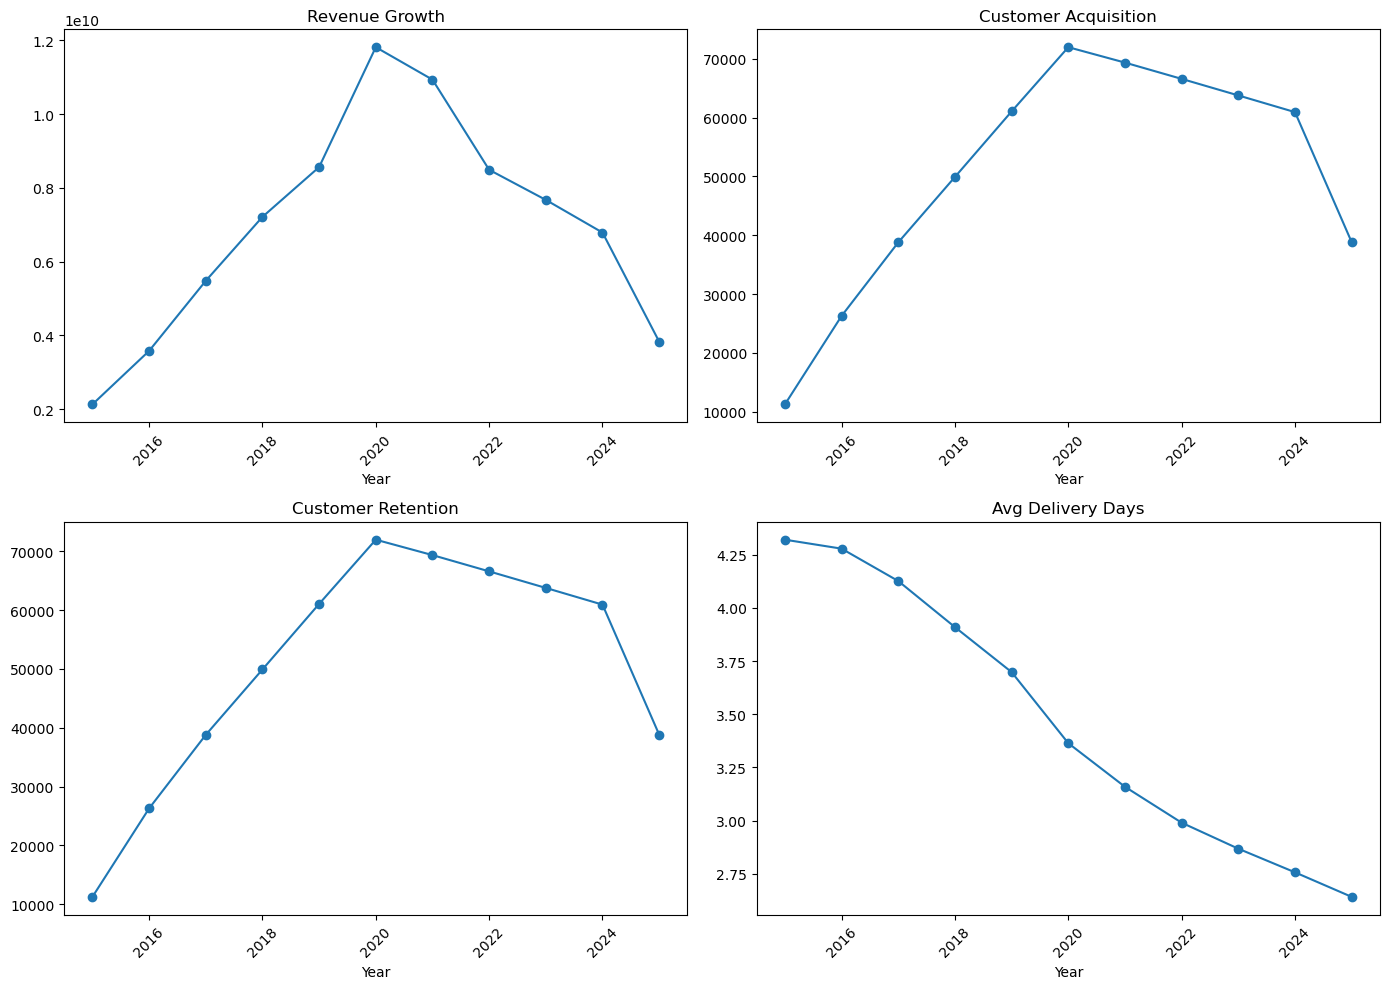

In [137]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Revenue Growth
axes[0,0].plot(revenue_trend.index, revenue_trend.values, marker='o')
axes[0,0].set_title("Revenue Growth")

# 2. Customer Acquisition
axes[0,1].plot(new_customers.index, new_customers.values, marker='o')
axes[0,1].set_title("Customer Acquisition")

# 3. Retention
axes[1,0].plot(retention.index, retention.values, marker='o')
axes[1,0].set_title("Customer Retention")

# 4. Delivery Efficiency
axes[1,1].plot(delivery_eff.index, delivery_eff.values, marker='o')
axes[1,1].set_title("Avg Delivery Days")

for ax in axes.flat:
    ax.set_xlabel("Year")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()